# Group second-level fMRI analysis (online TUS)

Aggregates first-level contrast maps across subjects, but will only run voxelwise group GLMs when MNI-warped maps are available. If only native-space maps are present, the notebook will summarize availability and ask you to warp to MNI first (see `resources/13_warp_contrasts_to_mni.py`).

In [1]:
from pathlib import Path
import importlib.util
import pandas as pd
import nibabel as nib
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting
import matplotlib.pyplot as plt
import ants 

# Paths and config
PROJECT_ROOT = Path("/Volumes/engram/CITRUS/online")
CONFIG_PATH = PROJECT_ROOT / 'scratch' / 'notebooks' / 'citrus_config.py'
FUNCTIONS_PATH = PROJECT_ROOT / 'scratch' / 'notebooks' / 'citrus_functions.py'

spec = importlib.util.spec_from_file_location('citrus_config', CONFIG_PATH)
cfg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# Load functions module
spec_func = importlib.util.spec_from_file_location('citrus_functions', FUNCTIONS_PATH)
cf = importlib.util.module_from_spec(spec_func)
spec_func.loader.exec_module(cf)

SUBJECTS = cfg.SUBJECTS
SESS_FUNC = cfg.SESS_FUNC
ANALYSIS_DIR = Path(cfg.ANALYSIS_DIR)
EXPECTED_CONTRASTS = cf.EXPECTED_CONTRASTS

print(f'Subjects: {SUBJECTS}')
print(f'Session: {SESS_FUNC}')
print(f'Analysis dir: {ANALYSIS_DIR}')


Subjects: ['sub-01', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-08', 'sub-09', 'sub-10', 'sub-11', 'sub-12', 'sub-13']
Session: ses-online
Analysis dir: /Volumes/engram/CITRUS/online/scratch/analysis


In [2]:
# Helpers
# We prefer MNI-warped maps if present; otherwise, we only summarize native-space maps.
# Group-level voxelwise GLM runs only when all contributing maps are in MNI space.

group_dir_mni = ANALYSIS_DIR / 'group' / 'second_level_MNI'
group_dir_native = ANALYSIS_DIR / 'group' / 'second_level_native'
for d in (group_dir_mni, group_dir_native):
    d.mkdir(parents=True, exist_ok=True)

def list_contrasts_with_space(subject):
    """Return list of (contrast_name, space) for a subject."""
    found = []
    mni_dir = ANALYSIS_DIR / subject / SESS_FUNC / 'glm_MNI'
    if mni_dir.exists():
        for f in mni_dir.glob(f'{subject}_{SESS_FUNC}_contrast-*_effect_space-MNI152NLin2009cAsym.nii.gz'):
            name = f.name
            name = name.replace(f'{subject}_{SESS_FUNC}_contrast-', '')
            name = name.replace('_effect_space-MNI152NLin2009cAsym.nii.gz', '')
            found.append((name, 'MNI'))
    native_dir = ANALYSIS_DIR / subject / SESS_FUNC / 'glm'
    if native_dir.exists():
        for f in native_dir.glob(f'{subject}_{SESS_FUNC}_contrast-*_effect.nii.gz'):
            name = f.name
            name = name.replace(f'{subject}_{SESS_FUNC}_contrast-', '')
            name = name.replace('_effect.nii.gz', '')
            found.append((name, 'native'))
    return found

def collect_subject_imgs(contrast, map_type='effect'):
    """ Return list of (subject, path, space) where contrast exists.
        For MNI space, expects files from warp_contrast_to_mni with names like:
        {sub}_{SESS_FUNC}_contrast-{contrast}_{map_type}_space-MNI152NLin2009cAsym.nii.gz
        For native space, uses original *_contrast-{contrast}_{map_type}.nii.gz files.
    """

    imgs = []
    for sub in SUBJECTS:
        # MNI space: warped files include map_type in name
        mni_path = (
            ANALYSIS_DIR
            / sub
            / SESS_FUNC
            / 'glm_MNI'
            / f'{sub}_{SESS_FUNC}_contrast-{contrast}_{map_type}_space-MNI152NLin2009cAsym.nii.gz'
        )
        # Native space: original files with map_type suffix
        native_path = (
            ANALYSIS_DIR
            / sub
            / SESS_FUNC
            / 'glm'
            / f'{sub}_{SESS_FUNC}_contrast-{contrast}_{map_type}.nii.gz'
        )
        if mni_path.exists():
            imgs.append((sub, mni_path, 'MNI'))
        elif native_path.exists():
            imgs.append((sub, native_path, 'native'))
    return imgs

def run_second_level(contrast, smoothing_fwhm=6.0, min_subjects=2, threshold=3.1, map_type='effect'):
    imgs = collect_subject_imgs(contrast, map_type=map_type)
    if len(imgs) < min_subjects:
        print(f'[SKIP] {contrast}: only {len(imgs)} subject(s) found.')
        return None
    spaces = {sp for _, _, sp in imgs}
    if spaces != {'MNI'}:
        print(f"[SKIP] {contrast}: need MNI-warped maps; found spaces={sorted(spaces)}. Run warping (e.g., resource 13_warp_contrasts_to_mni.py) first.")
        return None

    subjects, paths, _ = zip(*imgs)
    design_matrix = pd.DataFrame({'intercept': [1.0] * len(paths)})

    slm = SecondLevelModel(smoothing_fwhm=smoothing_fwhm)
    slm = slm.fit(list(paths), design_matrix=design_matrix)

    z_map = slm.compute_contrast('intercept', output_type='z_score')
    t_map = slm.compute_contrast('intercept', output_type='stat')

    z_out = group_dir_mni / f'group_contrast-{contrast}_zmap_space-MNI152NLin2009cAsym.nii.gz'
    t_out = group_dir_mni / f'group_contrast-{contrast}_tmap_space-MNI152NLin2009cAsym.nii.gz'
    z_map.to_filename(z_out)
    t_map.to_filename(t_out)
    print(f'[OK] {contrast}: saved Z to {z_out.name}; T to {t_out.name}')

    fig = plotting.plot_glass_brain(
        z_map,
        display_mode='lyrz',
        colorbar=True,
        plot_abs=False,
        threshold=threshold,
        title=f'group: {contrast} (Z)'
    )
    png_out = group_dir_mni / f'group_contrast-{contrast}_zmap_glass_brain.png'
    fig.savefig(png_out, dpi=150)
    plt.close('all')  # Close all matplotlib figures
    return {'contrast': contrast, 'subjects': subjects, 'z_map': z_out, 't_map': t_out, 'png': png_out}


## Step 1: Warp contrasts to MNI space

Warp all native-space contrast maps to MNI152NLin2009cAsym for group analysis.

In [3]:
# Warp all contrasts to MNI for all subjects
warp_results = {}
for sub in SUBJECTS:
    result = cf.warp_all_contrasts_to_mni(sub, cfg, contrast_list=EXPECTED_CONTRASTS, verbose=True)
    warp_results[sub] = result

# Summary
print("\n" + "="*60)
print("Warping Summary")
print("="*60)
for sub, result in warp_results.items():
    print(f"{sub}: {len(result['success'])} success, {len(result['skipped'])} skipped, {len(result['failed'])} failed")


Warping contrasts to MNI for sub-01
  [SKIP] exp_gt_con_overall (zmap): MNI file already exists: sub-01_ses-online_contrast-exp_gt_con_overall_zmap_space-MNI152NLin2009cAsym.nii.gz
  [SKIP] exp_gt_con_overall (tstat): MNI file already exists: sub-01_ses-online_contrast-exp_gt_con_overall_tstat_space-MNI152NLin2009cAsym.nii.gz
  [SKIP] exp_gt_con_overall (effect): MNI file already exists: sub-01_ses-online_contrast-exp_gt_con_overall_effect_space-MNI152NLin2009cAsym.nii.gz
  [SKIP] prot1_con_gt_baseline (zmap): MNI file already exists: sub-01_ses-online_contrast-prot1_con_gt_baseline_zmap_space-MNI152NLin2009cAsym.nii.gz
  [SKIP] prot1_con_gt_baseline (tstat): MNI file already exists: sub-01_ses-online_contrast-prot1_con_gt_baseline_tstat_space-MNI152NLin2009cAsym.nii.gz
  [SKIP] prot1_con_gt_baseline (effect): MNI file already exists: sub-01_ses-online_contrast-prot1_con_gt_baseline_effect_space-MNI152NLin2009cAsym.nii.gz
  [SKIP] prot1_exp_gt_baseline (zmap): MNI file already exists:

## Step 2: Inspect available contrasts

In [4]:
# Inspect available contrasts per subject (MNI or native)
# After warping, we should see MNI space maps
all_contrasts = set()
per_subject = {}
for sub in SUBJECTS:
    entries = list_contrasts_with_space(sub)
    per_subject[sub] = entries
    all_contrasts |= {c for c, _ in entries}

summary_rows = []
for contrast in sorted(all_contrasts):
    imgs = collect_subject_imgs(contrast)
    spaces = sorted({sp for _, _, sp in imgs})
    summary_rows.append({
        'contrast': contrast,
        'n_subjects': len(imgs),
        'spaces_found': ','.join(spaces) if spaces else 'none',
        'subjects': [s for s, _, _ in imgs],
    })
summary_df = pd.DataFrame(summary_rows).sort_values(['n_subjects', 'contrast'], ascending=[False, True])
summary_df.reset_index(drop=True, inplace=True)
summary_df


,contrast,n_subjects,spaces_found,subjects
0,exp_gt_con_overall,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
1,prot1_con_gt_baseline,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
2,prot1_exp_gt_baseline,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
3,prot1_exp_gt_con,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
4,prot2_con_gt_baseline,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
5,prot2_exp_gt_baseline,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
6,prot2_exp_gt_con,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
7,prot3_con_gt_baseline,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
8,prot3_exp_gt_baseline,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."
9,prot3_exp_gt_con,11,MNI,"[sub-01, sub-03, sub-04, sub-05, sub-06, sub-0..."


## Step 3: Run second-level group analysis

In [5]:
# Run second-level across contrasts with at least 2 subjects AND MNI-warped maps
# This should now work after warping in Step 1
results = []
for contrast in summary_df['contrast']:
    res = run_second_level(contrast)
    if res is not None:
        results.append(res)

pd.DataFrame(results)


[OK] exp_gt_con_overall: saved Z to group_contrast-exp_gt_con_overall_zmap_space-MNI152NLin2009cAsym.nii.gz; T to group_contrast-exp_gt_con_overall_tmap_space-MNI152NLin2009cAsym.nii.gz
[OK] prot1_con_gt_baseline: saved Z to group_contrast-prot1_con_gt_baseline_zmap_space-MNI152NLin2009cAsym.nii.gz; T to group_contrast-prot1_con_gt_baseline_tmap_space-MNI152NLin2009cAsym.nii.gz
[OK] prot1_exp_gt_baseline: saved Z to group_contrast-prot1_exp_gt_baseline_zmap_space-MNI152NLin2009cAsym.nii.gz; T to group_contrast-prot1_exp_gt_baseline_tmap_space-MNI152NLin2009cAsym.nii.gz
[OK] prot1_exp_gt_con: saved Z to group_contrast-prot1_exp_gt_con_zmap_space-MNI152NLin2009cAsym.nii.gz; T to group_contrast-prot1_exp_gt_con_tmap_space-MNI152NLin2009cAsym.nii.gz
[OK] prot2_con_gt_baseline: saved Z to group_contrast-prot2_con_gt_baseline_zmap_space-MNI152NLin2009cAsym.nii.gz; T to group_contrast-prot2_con_gt_baseline_tmap_space-MNI152NLin2009cAsym.nii.gz
[OK] prot2_exp_gt_baseline: saved Z to group_cont

,contrast,subjects,z_map,t_map,png
0,exp_gt_con_overall,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
1,prot1_con_gt_baseline,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
2,prot1_exp_gt_baseline,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
3,prot1_exp_gt_con,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
4,prot2_con_gt_baseline,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
5,prot2_exp_gt_baseline,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
6,prot2_exp_gt_con,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
7,prot3_con_gt_baseline,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
8,prot3_exp_gt_baseline,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...
9,prot3_exp_gt_con,"(sub-01, sub-03, sub-04, sub-05, sub-06, sub-0...",/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...,/Volumes/engram/CITRUS/online/scratch/analysis...


### Interactive visualization with adjustable parameters

Use the function below to visualize any contrast with customizable thresholds and correction methods.

## Step 4: Visualize results

In [6]:
# =========================
# One-peak-per-cluster report (NO subpeaks / no 1a,2b IDs)
# =========================

from nilearn.datasets import load_mni152_template
from nilearn.plotting import plot_stat_map, plot_glass_brain
from nilearn.glm import threshold_stats_img
from scipy import ndimage

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import siibra


# -------------------------
# Helpers
# -------------------------
def _extract_cluster_voxels(thr_img, used_threshold, two_sided=True):
    """
    Extract voxel indices for each suprathreshold connected component
    from a (typically) thresholded stat image.

    Returns
    -------
    cluster_voxels : dict
        cluster_id (1-based) -> array of ijk voxel indices (N, 3)
    labeled : ndarray
        labeled connected component image in voxel space
    """
    data = thr_img.get_fdata()

    if two_sided:
        mask = np.abs(data) >= used_threshold
    else:
        mask = data >= used_threshold

    labeled, n_clusters = ndimage.label(mask)

    cluster_voxels = {}
    for cid in range(1, n_clusters + 1):
        cluster_voxels[cid] = np.argwhere(labeled == cid)

    return cluster_voxels, labeled


def _clusters_peaks_table_one_peak(
    thr_img,
    used_threshold,
    cluster_threshold=10,
    two_sided=True,
):
    """
    Build a cluster table with exactly ONE row per cluster:
    the peak voxel (max abs if two_sided, max if one_sided).

    Parameters
    ----------
    thr_img : Nifti1Image
        Thresholded image (e.g., output of threshold_stats_img).
    used_threshold : float
        The voxelwise Z threshold (same used to make thr_img).
    cluster_threshold : int
        Minimum cluster size in voxels.
    two_sided : bool
        If True, clusters are defined by abs(data) >= threshold and
        peak is voxel with max abs value (keeping sign).

    Returns
    -------
    df : pd.DataFrame
        Columns:
        Cluster ID, X, Y, Z, Peak Stat, Cluster Size (vox), Cluster Size (mm3)
    cluster_voxels : dict
        Internal mapping of component-id (in label image) -> ijk indices.
        Note: component IDs here are the ndimage.label IDs, not the output IDs.
    """
    data = thr_img.get_fdata()
    affine = thr_img.affine

    # mask and label clusters
    cluster_voxels, labeled = _extract_cluster_voxels(
        thr_img, used_threshold, two_sided=two_sided
    )

    # voxel volume (mm^3)
    zooms = thr_img.header.get_zooms()[:3]
    vox_vol_mm3 = float(np.prod(zooms))

    rows = []
    out_id = 0

    # iterate clusters in label order
    for cid in sorted(cluster_voxels.keys()):
        ijk = cluster_voxels[cid]
        nvox = int(ijk.shape[0])
        if nvox < int(cluster_threshold):
            continue

        vals = data[ijk[:, 0], ijk[:, 1], ijk[:, 2]]

        # peak voxel inside the cluster
        if two_sided:
            peak_idx = int(np.argmax(np.abs(vals)))
        else:
            peak_idx = int(np.argmax(vals))

        peak_ijk = ijk[peak_idx]
        peak_val = float(vals[peak_idx])

        # convert voxel -> MNI/world coords
        peak_xyz = nib.affines.apply_affine(affine, peak_ijk)

        out_id += 1
        rows.append(
            {
                "Cluster ID": out_id,  # sequential integer IDs (no 1a/2b)
                "X": float(peak_xyz[0]),
                "Y": float(peak_xyz[1]),
                "Z": float(peak_xyz[2]),
                "Peak Stat": peak_val,
                "Cluster Size (vox)": nvox,
                "Cluster Size (mm3)": float(nvox * vox_vol_mm3),
                "_label_cid": int(cid),  # keep original label id (optional/debug)
            }
        )

    df = pd.DataFrame(rows)
    return df, cluster_voxels


def _siibra_assign_peak_julich(df, parcellation="julich 2.9", space="mni152", maptype="statistical"):
    """
    Add siibra Julich assignment for each peak coordinate in df.
    Expects df to contain columns X,Y,Z in MNI world coordinates.
    """
    if df is None or len(df) == 0:
        return df

    with siibra.QUIET:
        julich_pmaps = siibra.get_map(
            parcellation=parcellation,
            space=space,
            maptype=maptype,
        )

    regions = []
    mapvals = []

    for _, row in df.iterrows():
        peak_coords = (float(row["X"]), float(row["Y"]), float(row["Z"]))
        point = siibra.Point(peak_coords, space=space)

        with siibra.QUIET:
            assignments = julich_pmaps.assign(point)

        if assignments is None or len(assignments) == 0:
            regions.append("n/a")
            mapvals.append(np.nan)
            continue

        top = assignments.sort_values("map value", ascending=False).iloc[0]
        regions.append(str(top["region"]))
        mapvals.append(float(top["map value"]))

    df = df.copy()
    df["siibra_region"] = regions
    df["siibra_map_value"] = mapvals
    return df


# -------------------------
# Main function
# -------------------------
def visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name,
    group_dir_mni,                 # pathlib.Path
    threshold=3.1,                 # used only for uncorrected ("none")
    cluster_threshold=10,          # min cluster size in voxels
    correction="none",             # "fdr", "bonferroni", "fpr", or "none"
    alpha=0.05,                    # q or p depending on correction
    two_sided=True,                # keep True for typical fMRI
    view_type="glass",             # "glass" or "stat"
    show_plot=True,
    save_table=False,              # save TSV to disk
):
    """
    Threshold a group-level Z-map, find clusters, and return ONE peak per cluster (no subpeaks).
    Adds siibra Julich assignment at the peak coordinate.

    Returns
    -------
    clusters_table : pd.DataFrame or None
    used_threshold : float or None
    z_thresholded : Nifti1Image or None
    """
    # ---- load Z map
    z_file = (
        group_dir_mni
        / f"group_contrast-{contrast_name}_zmap_space-MNI152NLin2009cAsym.nii.gz"
    )

    if not z_file.exists():
        print(f"[ERROR] Z-map not found for {contrast_name}: {z_file}")
        return None, None, None

    z_img = nib.load(str(z_file))

    print("\n" + "=" * 80)
    print(f"Contrast: {contrast_name}")
    print("=" * 80)

    corr = (correction or "none").lower()

    # ---- thresholding
    if corr in ("fdr", "bonferroni", "fpr"):
        z_thresholded, used_threshold = threshold_stats_img(
            stat_img=z_img,
            alpha=alpha,
            height_control=corr,
            cluster_threshold=cluster_threshold,
            two_sided=two_sided,
        )
        print(
            f"{corr.upper()} correction: alpha={alpha}, "
            f"Z-threshold={used_threshold:.2f}, "
            f"cluster_size>={cluster_threshold} voxels, "
            f"two_sided={two_sided}"
        )
    elif corr in ("none", "uncorrected"):
        z_thresholded, used_threshold = threshold_stats_img(
            stat_img=z_img,
            threshold=threshold,
            height_control=None,
            cluster_threshold=cluster_threshold,
            two_sided=two_sided,
        )
        print(
            f"Uncorrected threshold: Z>={used_threshold:.2f}, "
            f"cluster_size>={cluster_threshold} voxels, "
            f"two_sided={two_sided}"
        )
    else:
        raise ValueError(
            f"Unknown correction '{correction}'. Use 'fdr', 'bonferroni', 'fpr', or 'none'."
        )

    # ---- one-peak-per-cluster table
    clusters_table, _ = _clusters_peaks_table_one_peak(
        z_thresholded,
        used_threshold=used_threshold,
        cluster_threshold=cluster_threshold,
        two_sided=two_sided,
    )

    if clusters_table is None or len(clusters_table) == 0:
        print("\nNo clusters found at this threshold.")
        return clusters_table, used_threshold, z_thresholded

    print(f"\nFound {len(clusters_table)} cluster(s) at Z>={used_threshold:.2f} (one peak per cluster).")

    # ---- siibra assignment at peak only (Julich)
    try:
        clusters_table = _siibra_assign_peak_julich(clusters_table)
    except Exception as e:
        print(f"\n[WARNING] siibra assignment failed: {e}")

    # drop debug column unless you want it
    if "_label_cid" in clusters_table.columns:
        clusters_table = clusters_table.drop(columns=["_label_cid"])

    # display in notebook if available
    try:
        display(clusters_table)
    except Exception:
        print(clusters_table)

    # ---- save table
    if save_table:
        out_tsv = group_dir_mni / f"group_contrast-{contrast_name}_clusters_{corr}_onepeak_siibra.tsv"
        clusters_table.to_csv(out_tsv, sep="\t", index=False)
        print(f"\n[OK] Saved cluster table to: {out_tsv}")

    # ---- visualization
    if show_plot:
        title = f"Group: {contrast_name} (Z, corr={corr}, thr={used_threshold:.2f})"
     
        if view_type == "glass":
            plot_glass_brain(
                z_thresholded,
                display_mode="lyrz",
                colorbar=True,
                plot_abs=False,     # keep sign visible
                threshold=used_threshold,
                title=title,
                figure=plt.figure(figsize=(12, 4)),
            )
        elif view_type == "stat":
            template = load_mni152_template(resolution=2)
            plot_stat_map(
                z_thresholded,
                bg_img=template,
                display_mode="ortho",
                colorbar=True,
                threshold=used_threshold,
                title=title,
                figure=plt.figure(figsize=(12, 4)),
            )
        else:
            raise ValueError("view_type must be 'glass' or 'stat'.")

        plt.show()

    return clusters_table, used_threshold, z_thresholded


# =========================
# Example call
# =========================
# clusters, thr, thr_img = visualize_and_report_contrast_one_peak_per_cluster(
#     contrast_name="exp_gt_con_overall",
#     group_dir_mni=group_dir_mni,   # must be a pathlib.Path
#     threshold=2.58,
#     cluster_threshold=30,
#     correction="none",
#     alpha=0.05,
#     two_sided=True,
#     view_type="glass",
#     show_plot=True,
#     save_table=True,
# )


[siibra:INFO] Version: 1.0.1-alpha.11
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.



Contrast: exp_gt_con_overall
Uncorrected threshold: Z>=2.70, cluster_size>=30 voxels, two_sided=True

Found 12 cluster(s) at Z>=2.70 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-38.5,-16.5,41.5,-3.820485,192,1536.0,Area 4p (PreCG) left,0.623994
1,2,-46.5,-38.5,27.5,3.577370,99,792.0,Area PFcm (IPL) left,0.688063
2,3,-34.5,33.5,5.5,3.698743,247,1976.0,Frontal-I (GapMap) left,0.212293
3,4,-34.5,3.5,43.5,3.932429,45,360.0,Frontal-II (GapMap) left,0.635574
4,5,-10.5,33.5,43.5,4.064835,205,1640.0,Frontal-I (GapMap) left,0.921653
5,6,-0.5,-24.5,5.5,3.389503,34,272.0,CGL (Metathalamus) right,0.000042
6,7,15.5,-0.5,19.5,3.400800,58,464.0,CGL (Metathalamus) right,0.000042
7,8,17.5,11.5,53.5,-3.173483,32,256.0,Area 6d3 (SFS) right,0.340648
8,9,31.5,-98.5,1.5,3.054958,55,440.0,"Area hOc2 (V2, 18) right",0.325755
9,10,49.5,-8.5,31.5,-3.573303,209,1672.0,Area 4p (PreCG) right,0.568671


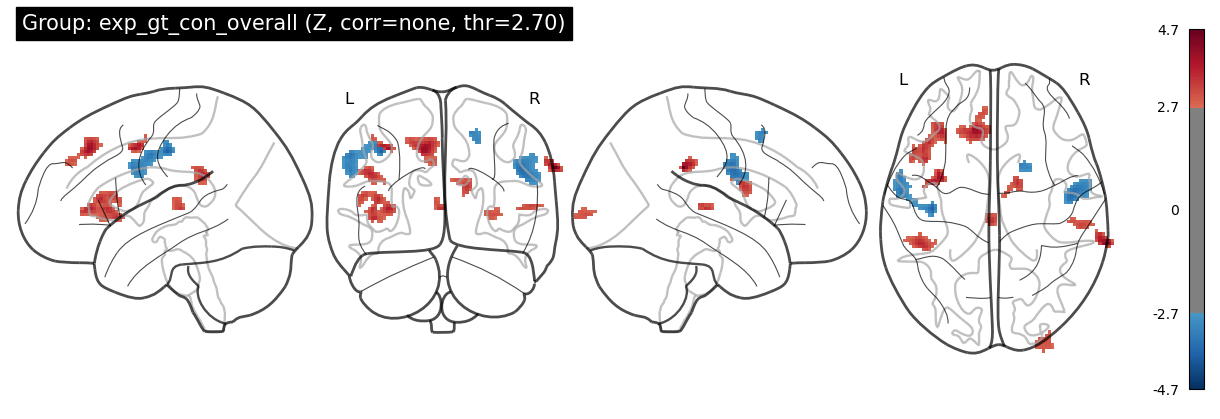

In [42]:
# Use the new one-peak-per-cluster function (no subpeaks / no 1a,2b IDs)
clusters_table, zthr, zthr_img = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="exp_gt_con_overall",
    group_dir_mni=group_dir_mni,   # make sure this is defined (pathlib.Path)
    threshold=2.7,
    cluster_threshold=30,
    correction="none",            # or "None" is fine; it's lowercased internally
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)



Contrast: prot1_exp_gt_con
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 9 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-42.5,-2.5,41.5,3.591665,63,504.0,Frontal-II (GapMap) left,0.996405
1,2,-16.5,-16.5,-28.5,3.966540,30,240.0,HC-Parasubiculum (Hippocampus) left,0.099822
2,3,-6.5,-104.5,5.5,3.233509,117,936.0,"Area hOc1 (V1, 17, CalcS) left",0.616704
3,4,-10.5,61.5,19.5,3.730875,63,504.0,Frontal-I (GapMap) left,0.977947
4,5,-14.5,29.5,45.5,3.948831,81,648.0,Frontal-I (GapMap) left,0.841384
5,6,13.5,-98.5,7.5,3.315248,95,760.0,"Area hOc1 (V1, 17, CalcS) right",0.709340
6,7,23.5,65.5,17.5,3.514207,35,280.0,Frontal-I (GapMap) right,0.274797
7,8,33.5,-98.5,17.5,2.919500,55,440.0,CGL (Metathalamus) right,0.000042
8,9,53.5,-78.5,5.5,3.695197,162,1296.0,Area hOc4la (LOC) right,0.160075


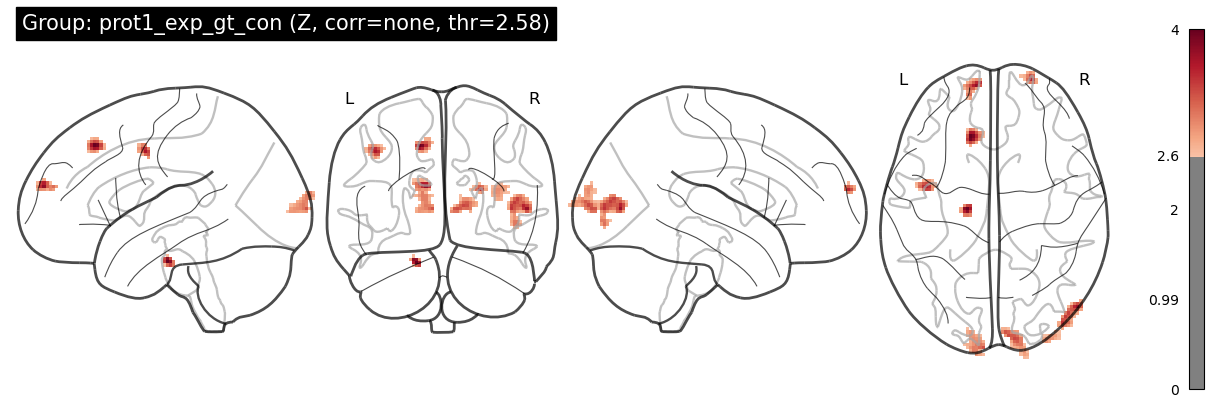


Contrast: prot2_exp_gt_con
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 11 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-52.5,-30.5,-14.5,3.965261,78,624.0,Temporal-to-Parietal (GapMap) left,0.523336
1,2,-36.5,25.5,63.5,-3.218705,33,264.0,CGL (Metathalamus) right,0.000042
2,3,-18.5,39.5,65.5,-3.044397,34,272.0,CGL (Metathalamus) right,0.000042
3,4,-18.5,-62.5,39.5,2.978117,37,296.0,Area hIP8 (IPS) left,0.122733
4,5,-14.5,-36.5,73.5,-3.731716,79,632.0,Area 5L (SPL) left,0.289979
5,6,-12.5,19.5,-8.5,3.614542,68,544.0,CGL (Metathalamus) right,0.000042
6,7,9.5,-14.5,69.5,-3.490505,325,2600.0,Area 6d1 (PreCG) right,0.886434
7,8,-6.5,5.5,1.5,3.358558,35,280.0,CGL (Metathalamus) right,0.000042
8,9,13.5,-56.5,53.5,3.991446,30,240.0,Area 7A (SPL) right,0.105470
9,10,25.5,33.5,63.5,-3.821846,156,1248.0,CGL (Metathalamus) right,0.000042


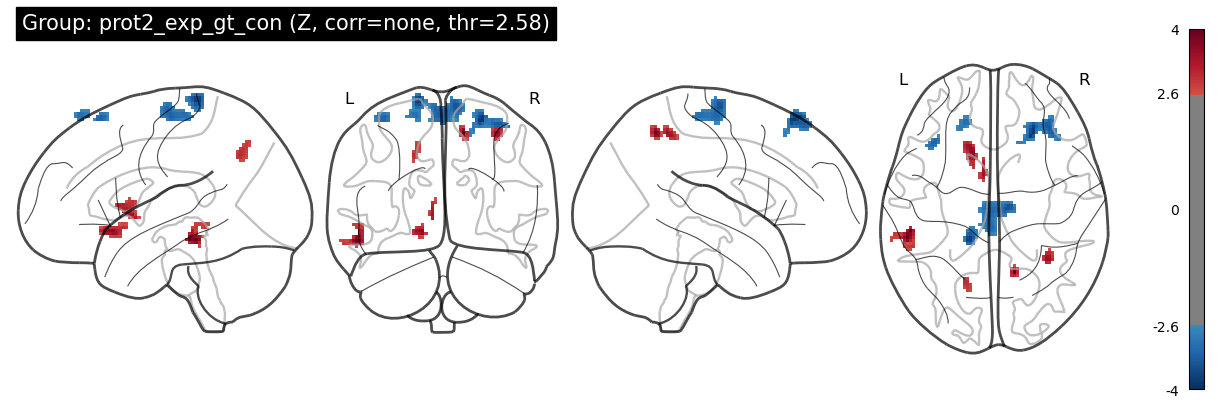


Contrast: prot3_exp_gt_con
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 9 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-54.5,5.5,29.5,-3.959874,73,584.0,Area 44 (IFG) left,0.425076
1,2,-32.5,-72.5,1.5,-3.369903,43,344.0,CGL (Metathalamus) right,0.000042
2,3,-8.5,-74.5,51.5,-3.470758,110,880.0,Area 7P (SPL) left,0.836289
3,4,7.5,-100.5,21.5,-3.496536,37,296.0,CGL (Metathalamus) right,0.000042
4,5,7.5,-70.5,53.5,-3.514894,63,504.0,Area 7P (SPL) right,0.508337
5,6,21.5,-76.5,61.5,-3.130233,59,472.0,CGL (Metathalamus) right,0.000042
6,7,23.5,-68.5,17.5,-3.709119,148,1184.0,Area hOc6 (POS) right,0.402722
7,8,17.5,13.5,51.5,-2.981761,34,272.0,Area 6d3 (SFS) right,0.374605
8,9,53.5,-14.5,-16.5,-3.717546,32,256.0,Area STS2 (STS) right,0.745319


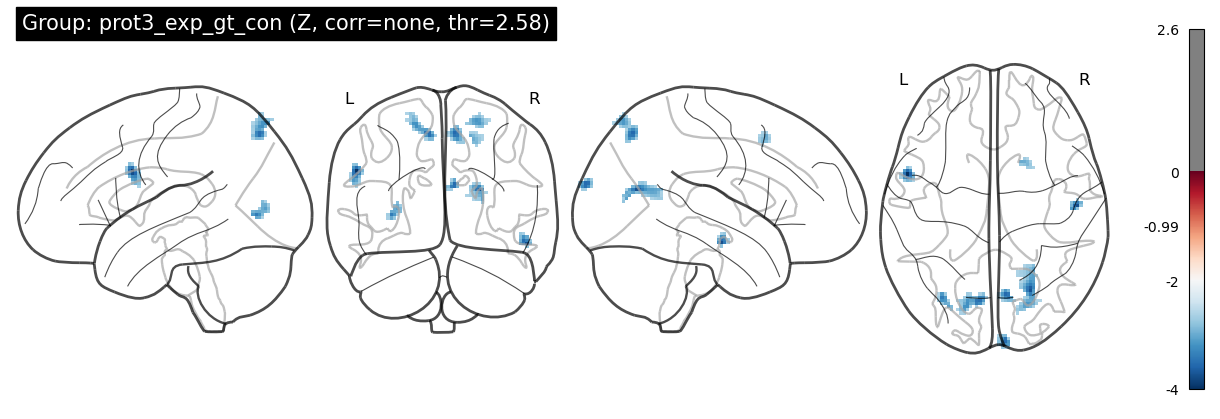


Contrast: prot4_exp_gt_con
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 15 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-60.5,-34.5,-2.5,2.989605,53,424.0,Temporal-to-Parietal (GapMap) left,0.473298
1,2,-52.5,-60.5,37.5,3.467211,40,320.0,Area PGa (IPL) left,0.625357
2,3,-50.5,-50.5,47.5,3.439692,107,856.0,Area PFm (IPL) left,0.406759
3,4,-34.5,21.5,-6.5,4.218708,284,2272.0,Area Id8 (Insula) left,0.675285
4,5,-40.5,15.5,55.5,3.260052,213,1704.0,Area 8v1 (MFG) left,0.374856
5,6,-26.5,55.5,3.5,3.392100,88,704.0,Area Fp1 (FPole) left,0.552617
6,7,-24.5,61.5,25.5,3.652380,44,352.0,Frontal-I (GapMap) left,0.409884
7,8,-20.5,7.5,17.5,3.850854,263,2104.0,CGL (Metathalamus) right,0.000042
8,9,-8.5,35.5,49.5,3.193721,31,248.0,Frontal-I (GapMap) left,1.000000
9,10,-8.5,43.5,25.5,3.283039,222,1776.0,Area p32 (pACC) left,0.567423


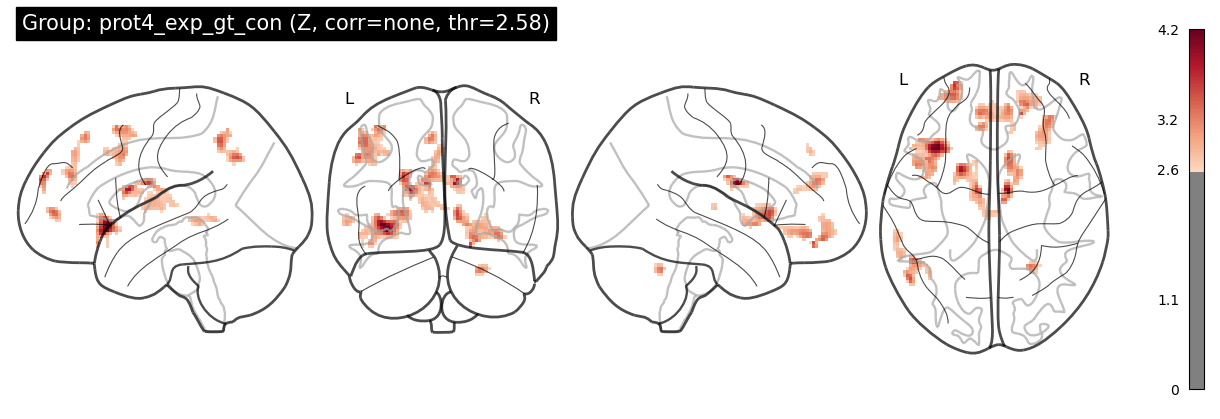

In [8]:
# One-peak-per-cluster calls (no subpeaks)
clusters_table_prot1, zthr_prot1, zthr_img_prot1 = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot1_exp_gt_con",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot2, zthr_prot2, zthr_img_prot2 = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot2_exp_gt_con",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot3, zthr_prot3, zthr_img_prot3 = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot3_exp_gt_con",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot4, zthr_prot4, zthr_img_prot4 = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot4_exp_gt_con",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)



Contrast: prot1_exp_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 6 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-62.5,-70.5,-2.5,3.565317,39,312.0,Temporal-to-Parietal (GapMap) left,0.221915
1,2,-10.5,-10.5,23.5,3.862123,45,360.0,CGL (Metathalamus) right,0.000042
2,3,-12.5,31.5,41.5,3.006934,65,520.0,Frontal-I (GapMap) left,0.589850
3,4,19.5,-106.5,7.5,3.449892,37,296.0,CGL (Metathalamus) right,0.000042
4,5,45.5,-90.5,-0.5,3.446300,161,1288.0,CGL (Metathalamus) right,0.000042
5,6,69.5,-0.5,43.5,-3.235976,144,1152.0,CGL (Metathalamus) right,0.000042


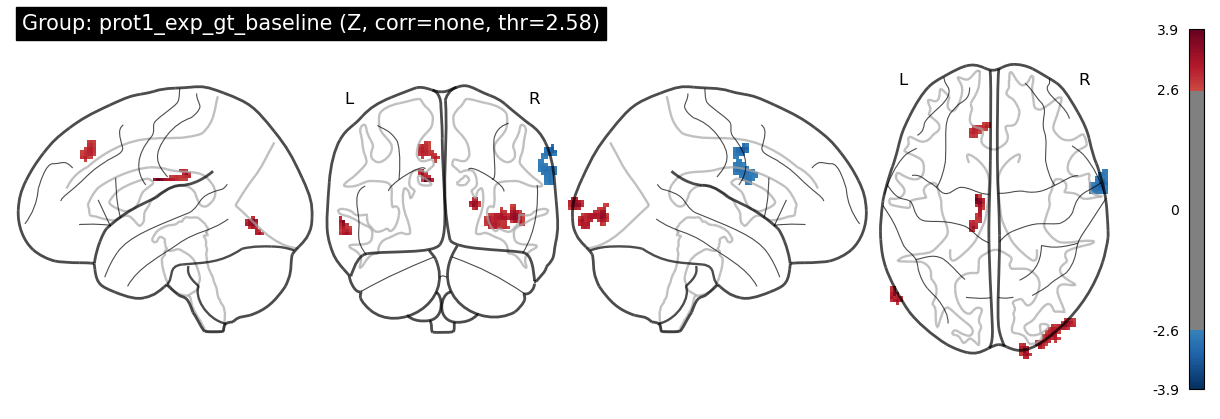


Contrast: prot2_exp_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 25 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-62.5,3.5,-20.5,-3.275982,36,288.0,Area STS2 (STS) left,0.069449
1,2,-52.5,17.5,11.5,3.710186,105,840.0,Area 44 (IFG) left,0.414589
2,3,-50.5,-6.5,35.5,-3.624263,170,1360.0,Frontal-II (GapMap) left,0.865938
3,4,-44.5,55.5,3.5,3.833584,66,528.0,Frontal-I (GapMap) left,0.955044
4,5,-40.5,-48.5,47.5,3.747153,114,912.0,Area hIP3 (IPS) left,0.369096
5,6,-26.5,25.5,9.5,3.534326,235,1880.0,Area Id7 (Insula) left,0.281816
6,7,-36.5,-40.5,21.5,3.464995,49,392.0,CGL (Metathalamus) right,0.000042
7,8,-24.5,-78.5,-4.5,-2.951712,40,320.0,Area hOc4v (LingG) left,0.615547
8,9,-14.5,-52.5,27.5,-3.839538,1373,10984.0,Frontal-to-Occipital (GapMap) left,0.664511
9,10,-22.5,-10.5,15.5,3.251715,31,248.0,CGL (Metathalamus) right,0.000042


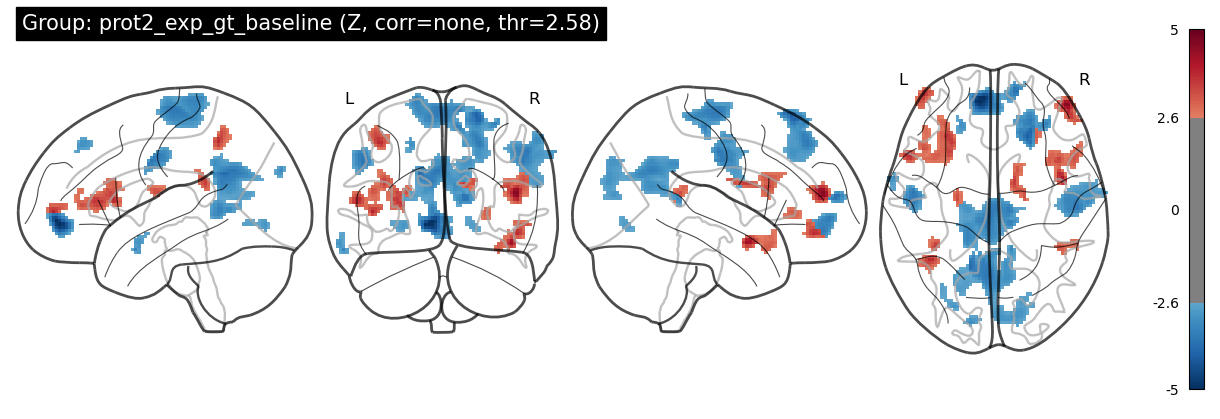


Contrast: prot3_exp_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 20 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-50.5,-42.5,11.5,3.509203,410,3280.0,Temporal-to-Parietal (GapMap) left,0.443617
1,2,-56.5,-44.5,63.5,3.094719,31,248.0,CGL (Metathalamus) right,0.000042
2,3,-48.5,11.5,25.5,3.900724,594,4752.0,Area 44 (IFG) left,0.499641
3,4,-32.5,35.5,7.5,3.711934,442,3536.0,Frontal-I (GapMap) left,0.590144
4,5,-46.5,33.5,19.5,2.988516,41,328.0,Frontal-I (GapMap) left,0.666513
5,6,-46.5,55.5,1.5,3.638619,42,336.0,Frontal-I (GapMap) left,0.187287
6,7,-40.5,27.5,49.5,3.106319,53,424.0,Area 8v1 (MFG) left,0.367895
7,8,-36.5,-60.5,3.5,-3.415981,47,376.0,CGL (Metathalamus) right,0.000042
8,9,-20.5,-42.5,-16.5,-3.347628,48,384.0,Area Ph3 (PhG) left,0.350550
9,10,-10.5,-54.5,-52.5,-3.095342,72,576.0,CGL (Metathalamus) right,0.000042


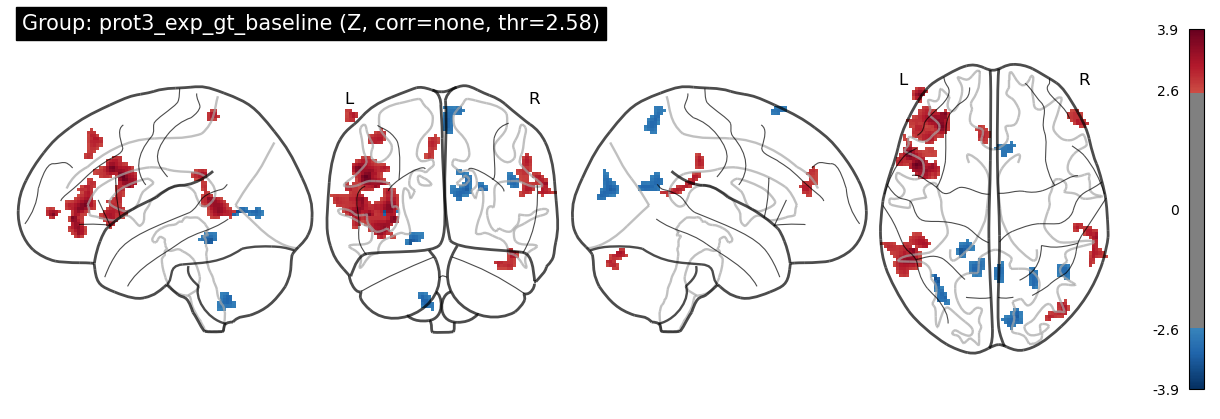


Contrast: prot4_exp_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 22 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-60.5,-36.5,-2.5,3.593930,306,2448.0,Temporal-to-Parietal (GapMap) left,0.930074
1,2,-44.5,-50.5,43.5,3.708630,577,4616.0,Area hIP2 (IPS) left,0.341510
2,3,-54.5,19.5,25.5,4.829881,2531,20248.0,Area 45 (IFG) left,0.491301
3,4,-46.5,-80.5,-24.5,3.213043,49,392.0,CGL (Metathalamus) right,0.000042
4,5,-42.5,-62.5,65.5,3.221274,77,616.0,CGL (Metathalamus) right,0.000042
5,6,-20.5,53.5,33.5,3.227340,111,888.0,Frontal-I (GapMap) left,0.988703
6,7,-10.5,15.5,13.5,3.677988,576,4608.0,CGL (Metathalamus) right,0.000042
7,8,-2.5,41.5,41.5,3.748187,765,6120.0,Frontal-I (GapMap) left,0.285332
8,9,-22.5,-44.5,77.5,-3.329699,35,280.0,Area 5L (SPL) left,0.306642
9,10,9.5,-28.5,49.5,-2.825907,36,288.0,Area 5Ci (SPL) right,0.213132


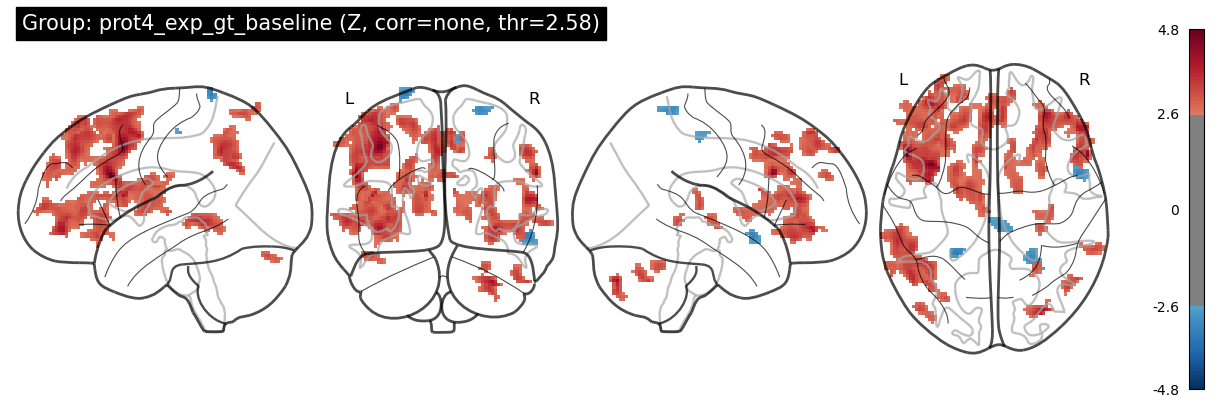

In [9]:
# One-peak-per-cluster calls (no subpeaks)
clusters_table_prot1_base, zthr_prot1_base, zthr_img_prot1_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot1_exp_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot2_base, zthr_prot2_base, zthr_img_prot2_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot2_exp_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot3_base, zthr_prot3_base, zthr_img_prot3_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot3_exp_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot4_base, zthr_prot4_base, zthr_img_prot4_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot4_exp_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)



Contrast: prot1_con_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 13 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-42.5,47.5,-10.5,3.271427,109,872.0,Area Fo6 (OFC) left,0.468758
1,2,-28.5,-42.5,-14.5,-3.061470,59,472.0,Area Ph2 (PhG) left,0.722587
2,3,-8.5,-10.5,67.5,-2.939025,37,296.0,Area 6d1 (PreCG) left,0.449848
3,4,9.5,-60.5,23.5,-3.270092,94,752.0,Frontal-to-Occipital (GapMap) right,0.976250
4,5,11.5,-10.5,67.5,-3.689020,210,1680.0,Area 6d1 (PreCG) right,0.817455
5,6,35.5,-90.5,29.5,-3.331456,198,1584.0,CGL (Metathalamus) right,0.000042
6,7,21.5,-52.5,63.5,-3.499403,138,1104.0,Area 5L (SPL) right,0.515155
7,8,41.5,-4.5,63.5,-2.907311,35,280.0,Frontal-II (GapMap) right,0.113645
8,9,47.5,-82.5,35.5,-3.575806,134,1072.0,CGL (Metathalamus) right,0.000042
9,10,49.5,-14.5,53.5,-2.805130,32,256.0,Area 1 (PostCG) right,0.819140


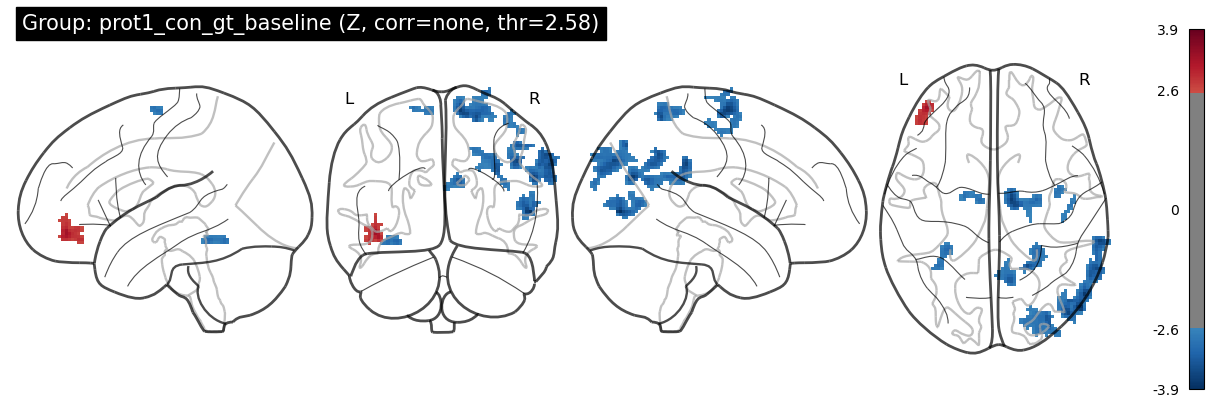


Contrast: prot2_con_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 22 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-50.5,-42.5,33.5,3.378401,76,608.0,Area hIP2 (IPS) left,0.189388
1,2,-32.5,3.5,25.5,4.043916,372,2976.0,CGL (Metathalamus) right,0.000042
2,3,-22.5,-50.5,-4.5,-4.371350,1032,8256.0,Frontal-to-Occipital (GapMap) left,0.452204
3,4,-20.5,-40.5,19.5,3.082133,151,1208.0,CGL (Metathalamus) right,0.000042
4,5,-28.5,21.5,-0.5,3.248383,49,392.0,Area Id7 (Insula) left,0.311340
5,6,-16.5,-80.5,39.5,-3.672500,145,1160.0,Area hPO1 (POS) left,0.706419
6,7,-10.5,-84.5,25.5,-2.918059,70,560.0,Area hOc3d (Cuneus) left,0.468348
7,8,1.5,-42.5,53.5,-3.024968,59,472.0,Area 5M (SPL) right,0.313031
8,9,1.5,55.5,57.5,3.336422,51,408.0,CGL (Metathalamus) right,0.000042
9,10,-0.5,-98.5,7.5,-3.460882,35,280.0,"Area hOc1 (V1, 17, CalcS) left",0.154359


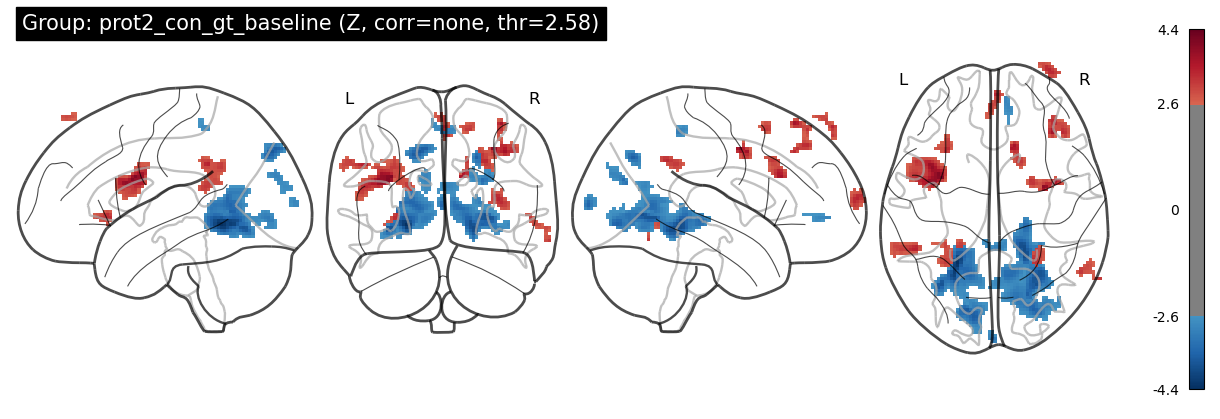


Contrast: prot3_con_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 24 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-66.5,-60.5,15.5,3.055739,41,328.0,Temporal-to-Parietal (GapMap) left,0.004976
1,2,-58.5,-76.5,-0.5,3.473314,72,576.0,Temporal-to-Parietal (GapMap) left,0.173008
2,3,-46.5,13.5,37.5,3.869670,723,5784.0,Area 44 (IFG) left,0.250694
3,4,-44.5,39.5,-0.5,3.257733,146,1168.0,Frontal-I (GapMap) left,0.993430
4,5,-48.5,33.5,11.5,3.277661,102,816.0,Area 45 (IFG) left,0.548282
5,6,-40.5,-56.5,71.5,3.648764,92,736.0,CGL (Metathalamus) right,0.000042
6,7,-36.5,17.5,17.5,3.900184,59,472.0,CGL (Metathalamus) right,0.000042
7,8,-32.5,-64.5,45.5,2.760763,64,512.0,Area hIP6 (IPS) left,0.528205
8,9,-28.5,21.5,-0.5,2.985547,101,808.0,Area Id7 (Insula) left,0.311340
9,10,-32.5,5.5,55.5,2.986511,48,384.0,Area 6d3 (SFS) left,0.311333


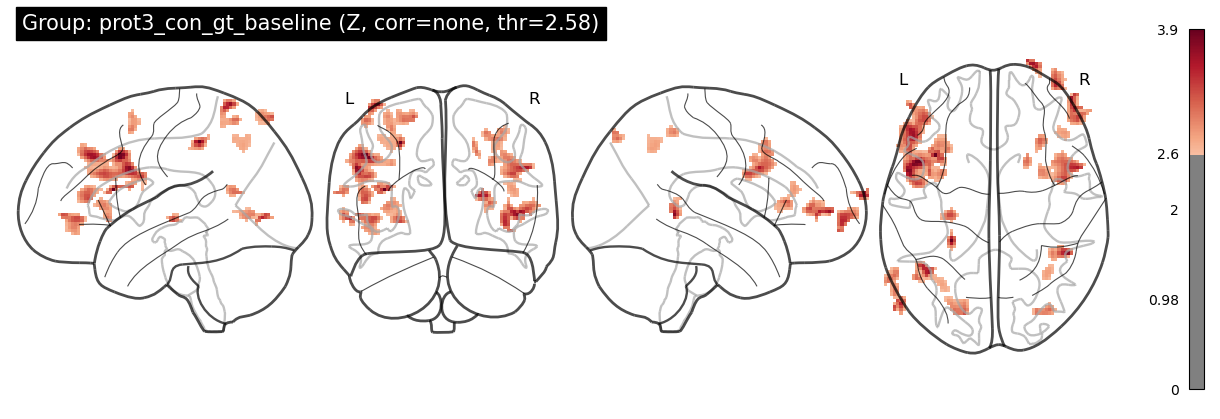


Contrast: prot4_con_gt_baseline
Uncorrected threshold: Z>=2.58, cluster_size>=30 voxels, two_sided=True

Found 3 cluster(s) at Z>=2.58 (one peak per cluster).


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (vox),Cluster Size (mm3),siibra_region,siibra_map_value
0,1,-28.5,-72.5,-42.5,3.162123,39,312.0,CGL (Metathalamus) right,0.000042
1,2,-4.5,35.5,-0.5,-4.232538,170,1360.0,Area p24ab (pACC) left,0.611964
2,3,19.5,57.5,-6.5,-3.123083,71,568.0,Area Fp1 (FPole) right,0.832672


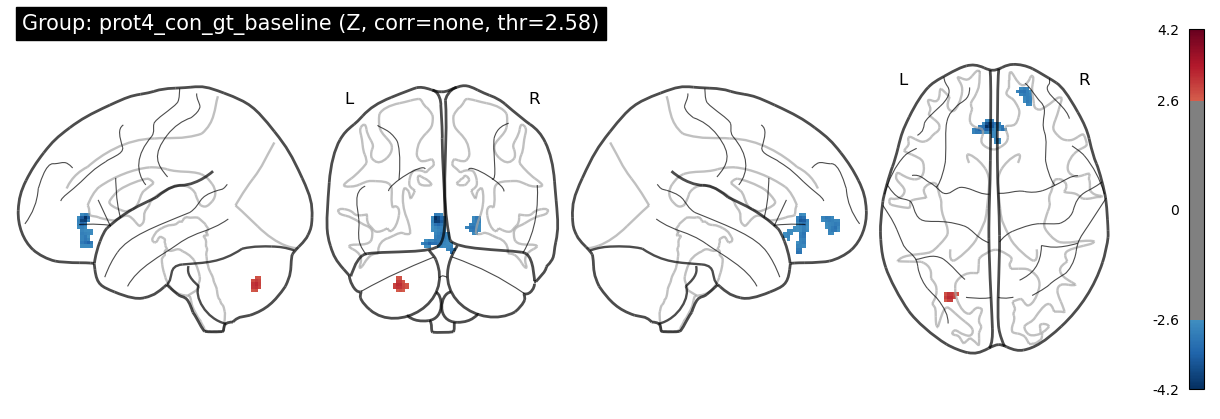

In [10]:
# One-peak-per-cluster calls (no subpeaks)
clusters_table_prot1_con_base, zthr_prot1_con_base, zthr_img_prot1_con_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot1_con_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot2_con_base, zthr_prot2_con_base, zthr_img_prot2_con_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot2_con_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot3_con_base, zthr_prot3_con_base, zthr_img_prot3_con_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot3_con_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)

clusters_table_prot4_con_base, zthr_prot4_con_base, zthr_img_prot4_con_base = visualize_and_report_contrast_one_peak_per_cluster(
    contrast_name="prot4_con_gt_baseline",
    group_dir_mni=group_dir_mni,
    threshold=2.58,
    cluster_threshold=30,
    correction="none",
    alpha=0.05,
    two_sided=True,
    show_plot=True,
    view_type="glass",
    save_table=False,
)


## Step 5: ROI Analysis for Percent Signal Change

Extract parameter estimates from ROIs and calculate percent signal change for group-level analysis. This follows best practices from the neuroimaging literature (Pernet et al., 2014; Gläscher, 2009).

**Percent Signal Change Calculation:**
- From GLM parameter estimates (beta values): PSC = (beta / intercept) × 100
- For contrasts: PSC = (effect_size / baseline_mean) × 100
- We extract mean effect sizes within ROIs and normalize by the intercept/baseline to get percent signal change


In [11]:
from nilearn.maskers import NiftiMasker
from nilearn.image import resample_to_img
import numpy as np
import seaborn as sns
from scipy import stats

# Set up ROI directory
roi_dir = ANALYSIS_DIR / 'group' / 'roi_analysis'
roi_dir.mkdir(parents=True, exist_ok=True)

def load_roi_mask(roi_name, space='MNI152NLin2009cAsym'):
    """
    Load ROI mask in MNI space.
    
    Parameters
    ----------
    roi_name : str
        ROI name from cfg.ROI_DEFS (e.g., 'L_sgACC_anat')
    space : str
        Space identifier (default: 'MNI152NLin2009cAsym')
    
    Returns
    -------
    nibabel.Nifti1Image or None
        ROI mask image, or None if not found
    """
    # Check if ROI exists in template directory
    roi_template_dir = cfg.ROI_TEMPLATE_DIR
    if not roi_template_dir.exists():
        print(f"  [WARNING] ROI template directory not found: {roi_template_dir}")
        return None
    
    # Find matching ROI definition
    roi_def = None
    for rd in cfg.ROI_DEFS:
        if rd['roi_name'] == roi_name:
            roi_def = rd
            break
    
    if roi_def is None:
        print(f"  [WARNING] ROI '{roi_name}' not found in ROI_DEFS")
        return None
    
    roi_file = roi_template_dir / roi_def['template_fname']
    if not roi_file.exists():
        print(f"  [WARNING] ROI file not found: {roi_file}")
        return None
    
    roi_img = nib.load(str(roi_file))
    return roi_img


def extract_roi_values(contrast_img, roi_mask, method='mean'):
    """
    Extract values from a contrast image within an ROI.
    
    Parameters
    ----------
    contrast_img : nibabel.Nifti1Image
        Contrast image (effect size map)
    roi_mask : nibabel.Nifti1Image
        ROI mask (binary or probabilistic)
    method : str
        'mean' (default) or 'max' for extraction method
    
    Returns
    -------
    float
        Extracted value
    """
    # Resample ROI to match contrast image if needed
    roi_resampled = resample_to_img(roi_mask, contrast_img, interpolation='nearest')
    
    # Get data
    contrast_data = contrast_img.get_fdata()
    roi_data = roi_resampled.get_fdata()
    
    # Mask: use voxels where ROI > 0
    mask = roi_data > 0
    if not np.any(mask):
        return np.nan
    
    values = contrast_data[mask]
    
    if method == 'mean':
        return np.nanmean(values)
    elif method == 'max':
        return np.nanmax(values)
    else:
        raise ValueError(f"Unknown method: {method}")


def extract_baseline_intercept(subject, space='MNI152NLin2009cAsym', roi_mask=None):
    """
    Extract mean intercept/baseline value from GLM for a subject.
    This is used to normalize effect sizes for percent signal change.
    
    Parameters
    ----------
    subject : str
        Subject ID
    space : str
        Space identifier
    roi_mask : nibabel.Nifti1Image, optional
        ROI mask to extract baseline within ROI (if None, uses whole brain mean)
    
    Returns
    -------
    float
        Mean intercept value (defaults to 100 if intercept map not found)
    
    Note
    ----
    This function first tries to find an intercept map saved from the GLM.
    If not found, it uses a default value of 100 (typical mean BOLD signal).
    For more accurate percent signal change, you should save intercept maps
    from your first-level GLM analysis.
    """
    mni_dir = ANALYSIS_DIR / subject / SESS_FUNC / 'glm_MNI'
    
    # Try to find an intercept map (if saved separately from GLM)
    intercept_patterns = [
        f'{subject}_{SESS_FUNC}_intercept_*_space-{space}.nii.gz',
        f'{subject}_{SESS_FUNC}_*_intercept_*_space-{space}.nii.gz',
    ]
    
    intercept_img = None
    for pattern in intercept_patterns:
        matches = list(mni_dir.glob(pattern))
        if matches:
            intercept_img = nib.load(str(matches[0]))
            break
    
    if intercept_img is not None:
        # Extract mean intercept value
        if roi_mask is not None:
            # Extract within ROI
            intercept_value = extract_roi_values(intercept_img, roi_mask, method='mean')
        else:
            # Use whole brain mean (excluding zeros)
            intercept_data = intercept_img.get_fdata()
            intercept_value = np.nanmean(intercept_data[intercept_data != 0])
        
        if not np.isnan(intercept_value) and intercept_value > 0:
            return float(intercept_value)
    
    # Default: use 100 (typical mean BOLD signal in arbitrary units)
    # This is a conservative estimate. For accurate PSC, save intercept maps from GLM.
    return 100.0


def calculate_percent_signal_change(effect_size, baseline_value):
    """
    Calculate percent signal change from effect size and baseline.
    
    Parameters
    ----------
    effect_size : float
        Parameter estimate (beta) from GLM
    baseline_value : float
        Baseline/intercept value for normalization
    
    Returns
    -------
    float
        Percent signal change
    """
    if baseline_value == 0 or np.isnan(baseline_value):
        return np.nan
    return (effect_size / baseline_value) * 100.0


def extract_roi_data_for_contrast(contrast_name, roi_name, map_type='effect', 
                                   space='MNI152NLin2009cAsym', method='mean'):
    """
    Extract ROI values for a contrast across all subjects.
    
    Parameters
    ----------
    contrast_name : str
        Name of contrast (e.g., 'prot1_exp_gt_con')
    roi_name : str
        ROI name (e.g., 'L_sgACC_anat')
    map_type : str
        'effect', 'tstat', or 'zmap'
    space : str
        Space identifier
    method : str
        'mean' or 'max' for extraction
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: subject, contrast, roi_name, effect_size, percent_signal_change
    """
    # Load ROI mask
    roi_mask = load_roi_mask(roi_name, space=space)
    if roi_mask is None:
        return pd.DataFrame()
    
    results = []
    
    for subject in SUBJECTS:
        # Load contrast image in MNI space
        mni_path = (
            ANALYSIS_DIR
            / subject
            / SESS_FUNC
            / 'glm_MNI'
            / f'{subject}_{SESS_FUNC}_contrast-{contrast_name}_{map_type}_space-{space}.nii.gz'
        )
        
        if not mni_path.exists():
            continue
        
        contrast_img = nib.load(str(mni_path))
        
        # Extract ROI value
        effect_size = extract_roi_values(contrast_img, roi_mask, method=method)
        
        if np.isnan(effect_size):
            continue
        
        # Get baseline for normalization (within ROI if possible)
        baseline = extract_baseline_intercept(subject, space=space, roi_mask=roi_mask)
        
        # Calculate percent signal change
        psc = calculate_percent_signal_change(effect_size, baseline)
        
        results.append({
            'subject': subject,
            'contrast': contrast_name,
            'roi_name': roi_name,
            'effect_size': effect_size,
            'baseline': baseline,
            'percent_signal_change': psc,
            'method': method
        })
    
    return pd.DataFrame(results)


def extract_roi_data_for_all_contrasts(contrast_list, roi_name, map_type='effect', 
                                       space='MNI152NLin2009cAsym', method='mean'):
    """
    Extract ROI data for multiple contrasts.
    
    Parameters
    ----------
    contrast_list : list
        List of contrast names
    roi_name : str
        ROI name
    map_type : str
        'effect', 'tstat', or 'zmap'
    space : str
        Space identifier
    method : str
        'mean' or 'max' for extraction
    
    Returns
    -------
    pd.DataFrame
        Combined results for all contrasts
    """
    all_results = []
    
    for contrast in contrast_list:
        df = extract_roi_data_for_contrast(contrast, roi_name, map_type, space, method)
        if not df.empty:
            all_results.append(df)
    
    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return pd.DataFrame()


print("ROI analysis functions loaded.")


ROI analysis functions loaded.


### Extract ROI data for all contrasts and ROIs


In [12]:
# Extract ROI data for all available contrasts and ROIs
# Get list of available contrasts from the summary
available_contrasts = summary_df['contrast'].tolist()

# Get ROI names from config
roi_names = [roi_def['roi_name'] for roi_def in cfg.ROI_DEFS]

print(f"Extracting ROI data for {len(available_contrasts)} contrasts and {len(roi_names)} ROIs...")
print(f"ROIs: {roi_names}")

# Extract data for all contrasts and ROIs
all_roi_data = []

for roi_name in roi_names:
    print(f"\nProcessing ROI: {roi_name}")
    roi_df = extract_roi_data_for_all_contrasts(
        available_contrasts, 
        roi_name, 
        map_type='effect',
        space='MNI152NLin2009cAsym',
        method='mean'
    )
    if not roi_df.empty:
        all_roi_data.append(roi_df)
        print(f"  Extracted data for {len(roi_df)} subject-contrast combinations")

if all_roi_data:
    roi_data_all = pd.concat(all_roi_data, ignore_index=True)
    
    # Save to CSV
    roi_csv = roi_dir / 'roi_data_all_contrasts.csv'
    roi_data_all.to_csv(roi_csv, index=False)
    print(f"\n[OK] Saved ROI data to: {roi_csv}")
    
    # Display summary
    print(f"\nSummary:")
    print(f"  Total rows: {len(roi_data_all)}")
    print(f"  Subjects: {roi_data_all['subject'].nunique()}")
    print(f"  Contrasts: {roi_data_all['contrast'].nunique()}")
    print(f"  ROIs: {roi_data_all['roi_name'].nunique()}")
    
    display(roi_data_all.head(10))
else:
    print("\n[WARNING] No ROI data extracted. Check ROI file paths and contrast availability.")
    roi_data_all = pd.DataFrame()


Extracting ROI data for 13 contrasts and 2 ROIs...
ROIs: ['sgACC_BA25_L', 'sgACC_BA25_R']

Processing ROI: sgACC_BA25_L


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/3048731014.py:72: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  roi_resampled = resample_to_img(roi_mask, contrast_img, interpolation='nearest')
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/3048731014.py:72: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  roi_resampled = resample_to_img(roi_mask, contrast_img, interpolation='nearest')
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/3048731014.py:72: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  roi_resampled = resample_to_img(roi_mask, contrast_img, interpola

  Extracted data for 143 subject-contrast combinations

Processing ROI: sgACC_BA25_R


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/3048731014.py:72: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  roi_resampled = resample_to_img(roi_mask, contrast_img, interpolation='nearest')
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/3048731014.py:72: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  roi_resampled = resample_to_img(roi_mask, contrast_img, interpolation='nearest')
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/3048731014.py:72: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  roi_resampled = resample_to_img(roi_mask, contrast_img, interpola

  Extracted data for 143 subject-contrast combinations

[OK] Saved ROI data to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_data_all_contrasts.csv

Summary:
  Total rows: 286
  Subjects: 11
  Contrasts: 13
  ROIs: 2


,subject,contrast,roi_name,effect_size,baseline,percent_signal_change,method
0,sub-01,exp_gt_con_overall,sgACC_BA25_L,0.003521,100.0,0.003521,mean
1,sub-03,exp_gt_con_overall,sgACC_BA25_L,-0.022813,100.0,-0.022813,mean
2,sub-04,exp_gt_con_overall,sgACC_BA25_L,0.007937,100.0,0.007937,mean
3,sub-05,exp_gt_con_overall,sgACC_BA25_L,-0.007756,100.0,-0.007756,mean
4,sub-06,exp_gt_con_overall,sgACC_BA25_L,0.004226,100.0,0.004226,mean
5,sub-08,exp_gt_con_overall,sgACC_BA25_L,0.018850,100.0,0.018850,mean
6,sub-09,exp_gt_con_overall,sgACC_BA25_L,-0.097151,100.0,-0.097151,mean
7,sub-10,exp_gt_con_overall,sgACC_BA25_L,0.012842,100.0,0.012842,mean
8,sub-11,exp_gt_con_overall,sgACC_BA25_L,0.006697,100.0,0.006697,mean
9,sub-12,exp_gt_con_overall,sgACC_BA25_L,0.034435,100.0,0.034435,mean


### Group-level statistics and visualization


In [13]:
def compute_group_stats(roi_data, contrast_name=None, roi_name=None):
    """
    Compute group-level statistics for ROI data.
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        ROI data from extract_roi_data_for_all_contrasts
    contrast_name : str, optional
        Filter by contrast name
    roi_name : str, optional
        Filter by ROI name
    
    Returns
    -------
    pd.DataFrame
        Summary statistics
    """
    df = roi_data.copy()
    
    if contrast_name:
        df = df[df['contrast'] == contrast_name]
    if roi_name:
        df = df[df['roi_name'] == roi_name]
    
    if df.empty:
        return pd.DataFrame()
    
    # Group by contrast and ROI
    grouped = df.groupby(['contrast', 'roi_name'])
    
    stats_list = []
    for (contrast, roi), group in grouped:
        psc_values = group['percent_signal_change'].dropna()
        
        if len(psc_values) == 0:
            continue
        
        stats_list.append({
            'contrast': contrast,
            'roi_name': roi,
            'n_subjects': len(psc_values),
            'mean_psc': psc_values.mean(),
            'std_psc': psc_values.std(),
            'sem_psc': stats.sem(psc_values) if len(psc_values) > 1 else np.nan,
            'median_psc': psc_values.median(),
            'min_psc': psc_values.min(),
            'max_psc': psc_values.max(),
            'mean_effect_size': group['effect_size'].mean(),
        })
    
    return pd.DataFrame(stats_list)


def plot_roi_percent_signal_change(roi_data, contrast_name, roi_names=None, 
                                   figsize=(10, 6), save_path=None):
    """
    Plot percent signal change for a contrast across ROIs.
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        ROI data
    contrast_name : str
        Contrast to plot
    roi_names : list, optional
        Specific ROIs to plot (if None, plots all)
    figsize : tuple
        Figure size
    save_path : Path, optional
        Path to save figure
    """
    df = roi_data[roi_data['contrast'] == contrast_name].copy()
    
    if df.empty:
        print(f"No data found for contrast: {contrast_name}")
        return
    
    if roi_names:
        df = df[df['roi_name'].isin(roi_names)]
    
    if df.empty:
        print(f"No data found for specified ROIs")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot with error bars
    ax1 = axes[0]
    stats_df = compute_group_stats(df, contrast_name=contrast_name)
    
    if not stats_df.empty:
        x_pos = np.arange(len(stats_df))
        bars = ax1.bar(x_pos, stats_df['mean_psc'], 
                      yerr=stats_df['sem_psc'], 
                      capsize=5, alpha=0.7, color='steelblue')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(stats_df['roi_name'], rotation=45, ha='right')
        ax1.set_ylabel('Percent Signal Change (%)')
        ax1.set_title(f'{contrast_name}\nGroup Mean ± SEM')
        ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax1.grid(axis='y', alpha=0.3)
    
    # Violin plot with individual data points
    ax2 = axes[1]
    sns.violinplot(data=df, x='roi_name', y='percent_signal_change', 
                   ax=ax2, inner='box', palette='Set2')
    sns.stripplot(data=df, x='roi_name', y='percent_signal_change', 
                  ax=ax2, color='black', alpha=0.5, size=4)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.set_ylabel('Percent Signal Change (%)')
    ax2.set_title(f'{contrast_name}\nDistribution across subjects')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")
    
    plt.show()


def plot_roi_comparison(roi_data, contrast_list, roi_name, figsize=(12, 6), save_path=None):
    """
    Compare percent signal change across multiple contrasts for a single ROI.
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        ROI data
    contrast_list : list
        List of contrasts to compare
    roi_name : str
        ROI name
    figsize : tuple
        Figure size
    save_path : Path, optional
        Path to save figure
    """
    df = roi_data[
        (roi_data['contrast'].isin(contrast_list)) & 
        (roi_data['roi_name'] == roi_name)
    ].copy()
    
    if df.empty:
        print(f"No data found for ROI: {roi_name}")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot
    ax1 = axes[0]
    stats_df = compute_group_stats(df, roi_name=roi_name)
    stats_df = stats_df[stats_df['contrast'].isin(contrast_list)]
    
    if not stats_df.empty:
        x_pos = np.arange(len(stats_df))
        bars = ax1.bar(x_pos, stats_df['mean_psc'], 
                      yerr=stats_df['sem_psc'], 
                      capsize=5, alpha=0.7, color='steelblue')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(stats_df['contrast'], rotation=45, ha='right')
        ax1.set_ylabel('Percent Signal Change (%)')
        ax1.set_title(f'{roi_name}\nGroup Mean ± SEM')
        ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax1.grid(axis='y', alpha=0.3)
    
    # Violin plot
    ax2 = axes[1]
    sns.violinplot(data=df, x='contrast', y='percent_signal_change', 
                   ax=ax2, inner='box', palette='Set2')
    sns.stripplot(data=df, x='contrast', y='percent_signal_change', 
                  ax=ax2, color='black', alpha=0.5, size=4)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.set_ylabel('Percent Signal Change (%)')
    ax2.set_title(f'{roi_name}\nDistribution across subjects')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")
    
    plt.show()


print("Visualization functions loaded.")


Visualization functions loaded.


In [14]:
# Compute group-level statistics for all contrasts and ROIs
if not roi_data_all.empty:
    group_stats = compute_group_stats(roi_data_all)
    
    if not group_stats.empty:
        # Save statistics table
        stats_csv = roi_dir / 'roi_group_statistics.csv'
        group_stats.to_csv(stats_csv, index=False)
        print(f"[OK] Saved group statistics to: {stats_csv}")
        
        # Display table
        display(group_stats.sort_values(['contrast', 'roi_name']))
        
        # Print summary by contrast
        print("\n" + "="*80)
        print("Summary by Contrast:")
        print("="*80)
        for contrast in group_stats['contrast'].unique():
            contrast_stats = group_stats[group_stats['contrast'] == contrast]
            print(f"\n{contrast}:")
            for _, row in contrast_stats.iterrows():
                print(f"  {row['roi_name']:20s}: {row['mean_psc']:6.2f}% ± {row['sem_psc']:5.2f}% (n={row['n_subjects']})")
else:
    print("No ROI data available for statistics.")


[OK] Saved group statistics to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_group_statistics.csv


,contrast,roi_name,n_subjects,mean_psc,std_psc,sem_psc,median_psc,min_psc,max_psc,mean_effect_size
0,exp_gt_con_overall,sgACC_BA25_L,11,-0.003462,0.034253,0.010328,0.004226,-0.097151,0.034435,-0.003462
1,exp_gt_con_overall,sgACC_BA25_R,11,-0.003212,0.016807,0.005068,-0.003305,-0.040450,0.022498,-0.003212
2,prot1_con_gt_baseline,sgACC_BA25_L,11,-0.023025,0.164414,0.049573,-0.056121,-0.217261,0.252569,-0.023025
3,prot1_con_gt_baseline,sgACC_BA25_R,11,-0.052242,0.259348,0.078196,-0.000772,-0.683798,0.260484,-0.052242
4,prot1_exp_gt_baseline,sgACC_BA25_L,11,-0.053463,0.183595,0.055356,-0.030860,-0.347174,0.285241,-0.053463
5,prot1_exp_gt_baseline,sgACC_BA25_R,11,-0.134456,0.235845,0.071110,-0.054365,-0.715750,0.099377,-0.134456
6,prot1_exp_gt_con,sgACC_BA25_L,11,-0.015219,0.141260,0.042591,-0.017659,-0.266536,0.237806,-0.015219
7,prot1_exp_gt_con,sgACC_BA25_R,11,-0.041107,0.184651,0.055674,-0.046998,-0.488117,0.254354,-0.041107
8,prot2_con_gt_baseline,sgACC_BA25_L,11,0.081709,0.253894,0.076552,0.053984,-0.353841,0.528012,0.081709
9,prot2_con_gt_baseline,sgACC_BA25_R,11,-0.003540,0.145932,0.044000,0.007846,-0.219216,0.303565,-0.003540



Summary by Contrast:

exp_gt_con_overall:
  sgACC_BA25_L        :  -0.00% ±  0.01% (n=11)
  sgACC_BA25_R        :  -0.00% ±  0.01% (n=11)

prot1_con_gt_baseline:
  sgACC_BA25_L        :  -0.02% ±  0.05% (n=11)
  sgACC_BA25_R        :  -0.05% ±  0.08% (n=11)

prot1_exp_gt_baseline:
  sgACC_BA25_L        :  -0.05% ±  0.06% (n=11)
  sgACC_BA25_R        :  -0.13% ±  0.07% (n=11)

prot1_exp_gt_con:
  sgACC_BA25_L        :  -0.02% ±  0.04% (n=11)
  sgACC_BA25_R        :  -0.04% ±  0.06% (n=11)

prot2_con_gt_baseline:
  sgACC_BA25_L        :   0.08% ±  0.08% (n=11)
  sgACC_BA25_R        :  -0.00% ±  0.04% (n=11)

prot2_exp_gt_baseline:
  sgACC_BA25_L        :   0.19% ±  0.09% (n=11)
  sgACC_BA25_R        :  -0.00% ±  0.05% (n=11)

prot2_exp_gt_con:
  sgACC_BA25_L        :   0.05% ±  0.04% (n=11)
  sgACC_BA25_R        :  -0.00% ±  0.03% (n=11)

prot3_con_gt_baseline:
  sgACC_BA25_L        :   0.32% ±  0.32% (n=11)
  sgACC_BA25_R        :   0.05% ±  0.04% (n=11)

prot3_exp_gt_baseline:
  sgACC

### Visualize ROI percent signal change

Plot percent signal change for key contrasts and ROIs.


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_psc_exp_gt_con_overall.png


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='roi_name', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


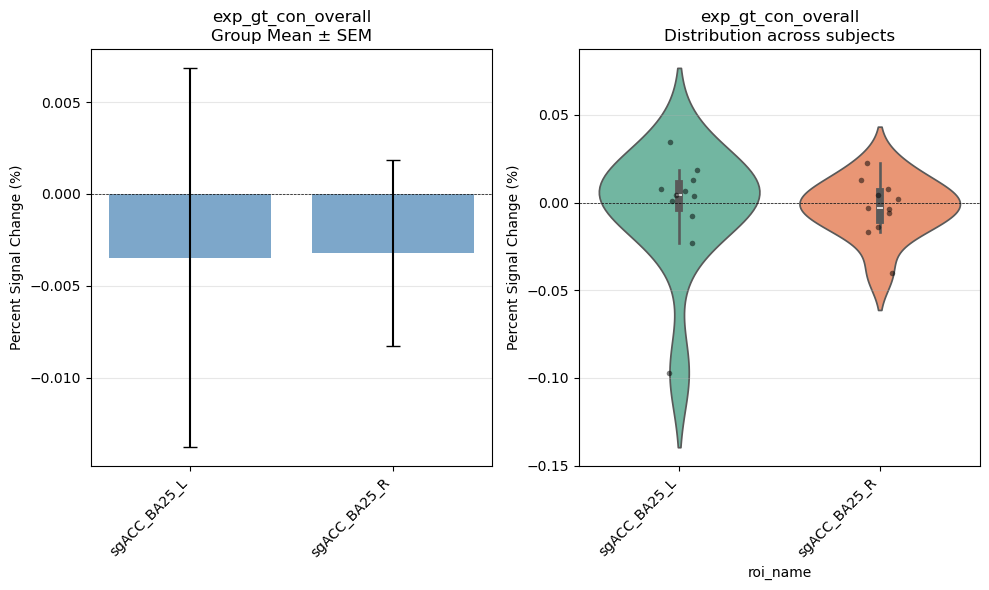

/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='roi_name', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_psc_prot1_exp_gt_con.png


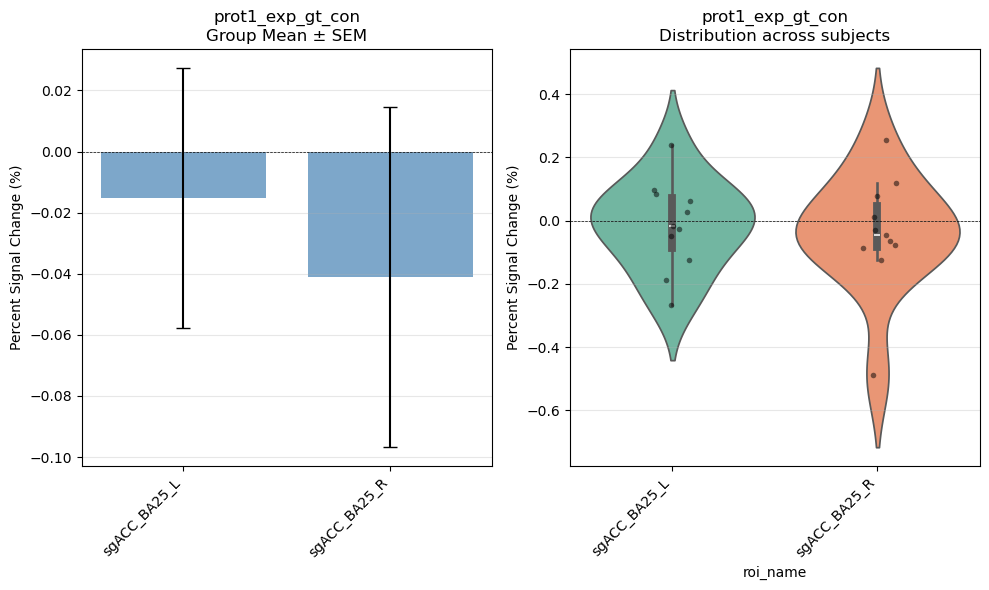

/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='roi_name', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_psc_prot2_exp_gt_con.png


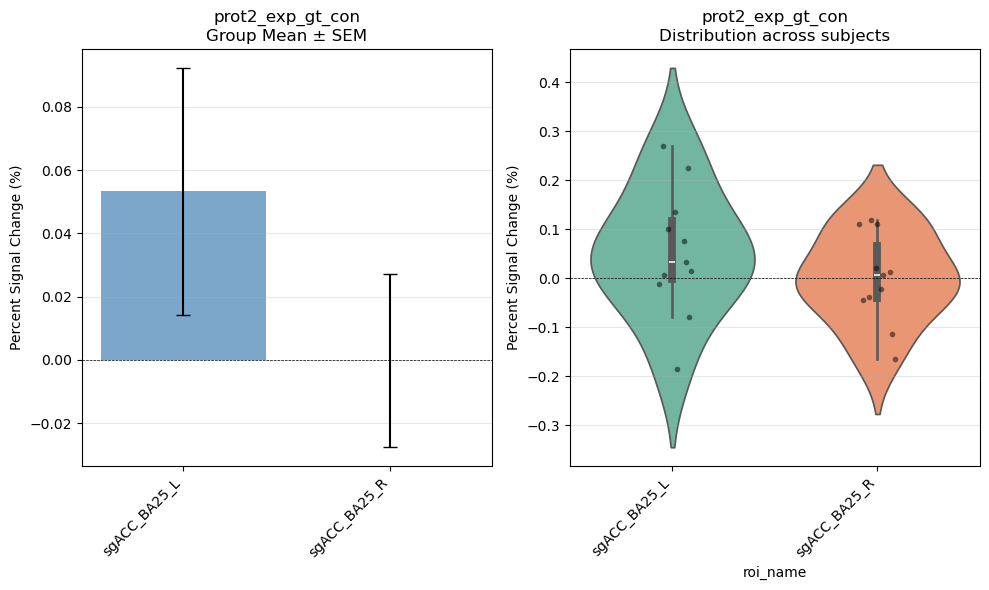

/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='roi_name', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_psc_prot3_exp_gt_con.png


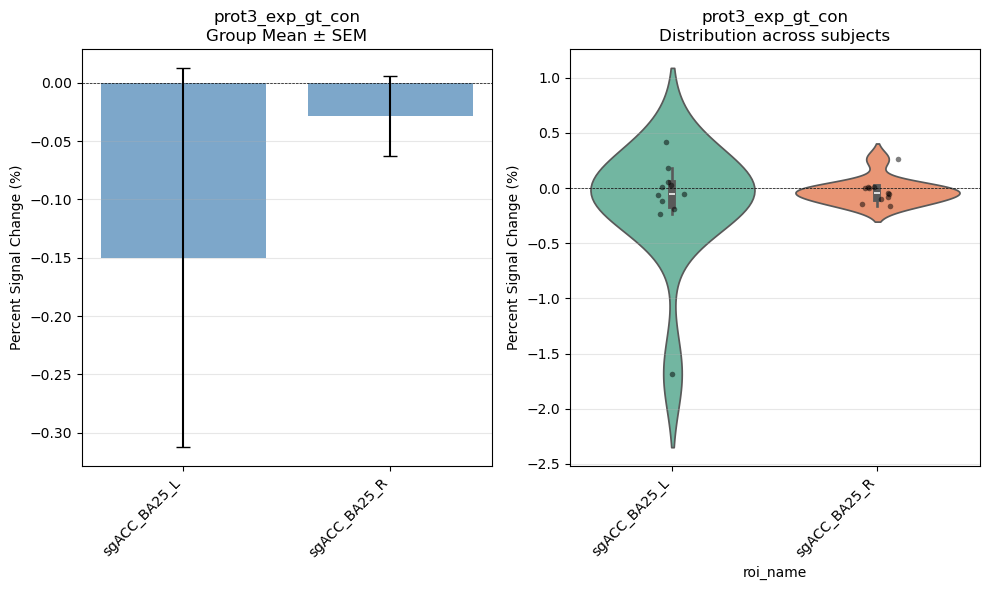

/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='roi_name', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_psc_prot4_exp_gt_con.png


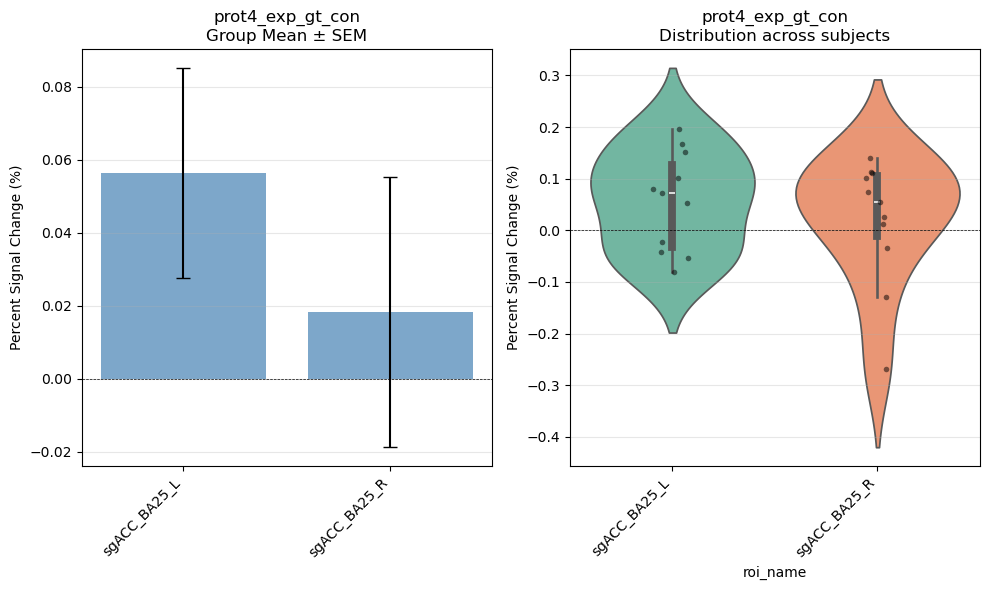

In [15]:
# Example: Plot percent signal change for key contrasts
if not roi_data_all.empty:
    # Plot overall exp > con contrast
    if 'exp_gt_con_overall' in roi_data_all['contrast'].values:
        plot_roi_percent_signal_change(
            roi_data_all, 
            'exp_gt_con_overall',
            save_path=roi_dir / 'roi_psc_exp_gt_con_overall.png'
        )
    
    # Plot protocol-specific contrasts
    for prot in ['prot1', 'prot2', 'prot3', 'prot4']:
        contrast_name = f'{prot}_exp_gt_con'
        if contrast_name in roi_data_all['contrast'].values:
            plot_roi_percent_signal_change(
                roi_data_all,
                contrast_name,
                save_path=roi_dir / f'roi_psc_{contrast_name}.png'
            )
else:
    print("No ROI data available for visualization.")


### Compare contrasts within each ROI


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='contrast', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_comparison_sgACC_BA25_L_protocols.png


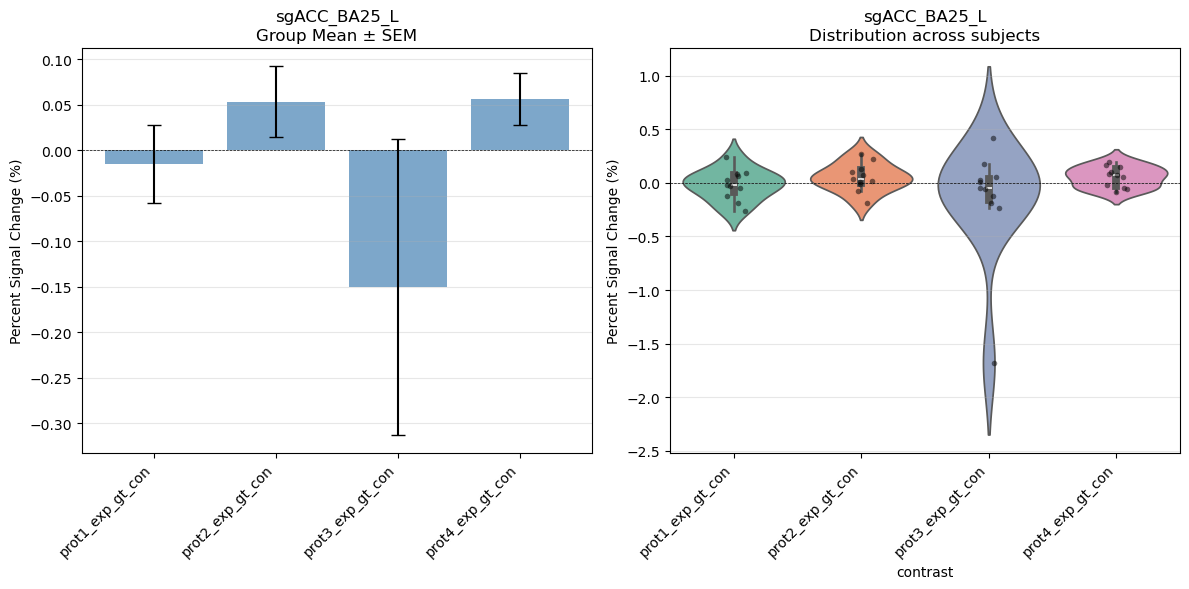

/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='contrast', y='percent_signal_change',
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_5669/1440607874.py:176: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_comparison_sgACC_BA25_R_protocols.png


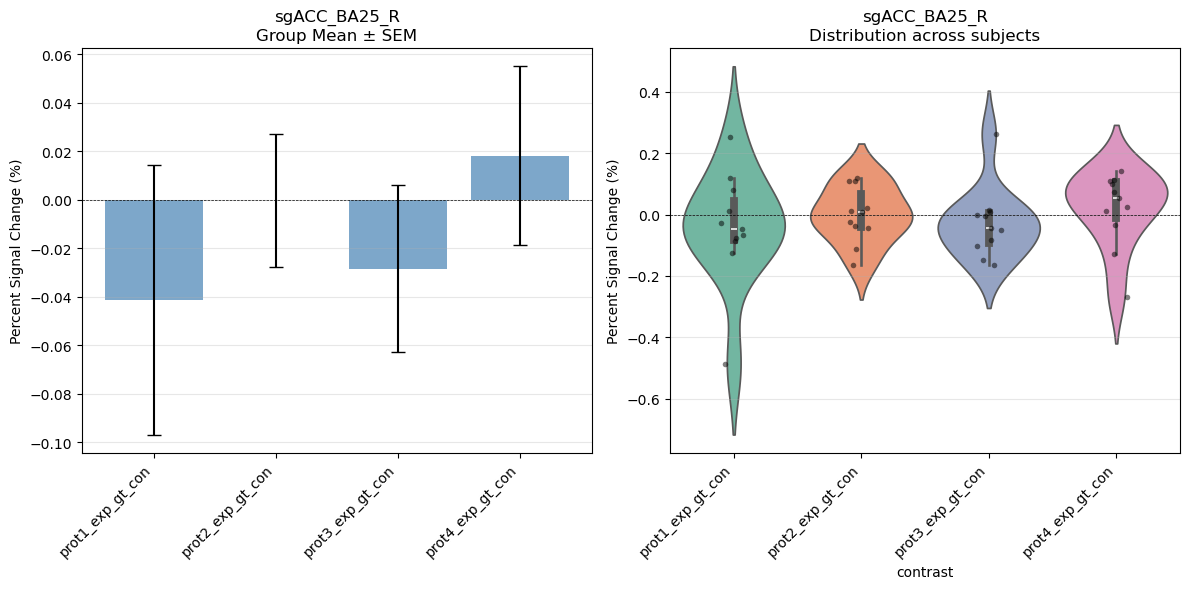

In [16]:
# Compare protocol-specific exp > con contrasts within each ROI
if not roi_data_all.empty:
    # Get protocol contrasts
    protocol_contrasts = [f'prot{i}_exp_gt_con' for i in [1, 2, 3, 4]]
    available_protocol_contrasts = [c for c in protocol_contrasts 
                                   if c in roi_data_all['contrast'].values]
    
    if available_protocol_contrasts:
        for roi_name in roi_names:
            plot_roi_comparison(
                roi_data_all,
                available_protocol_contrasts,
                roi_name,
                save_path=roi_dir / f'roi_comparison_{roi_name}_protocols.png'
            )
else:
    print("No ROI data available for comparison plots.")


### Statistical tests

Perform one-sample t-tests to test if percent signal change is significantly different from zero.


In [17]:
def perform_statistical_tests(roi_data):
    """
    Perform one-sample t-tests to test if percent signal change differs from zero.
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        ROI data
    
    Returns
    -------
    pd.DataFrame
        Results with t-statistics and p-values
    """
    results = []
    
    for (contrast, roi), group in roi_data.groupby(['contrast', 'roi_name']):
        psc_values = group['percent_signal_change'].dropna()
        
        if len(psc_values) < 2:
            continue
        
        # One-sample t-test against zero
        t_stat, p_value = stats.ttest_1samp(psc_values, 0)
        
        results.append({
            'contrast': contrast,
            'roi_name': roi,
            'n_subjects': len(psc_values),
            'mean_psc': psc_values.mean(),
            'std_psc': psc_values.std(),
            't_statistic': t_stat,
            'p_value': p_value,
            'p_value_fdr': np.nan,  # Will fill after
            'significant': p_value < 0.05,
            'significant_fdr': False,  # Will fill after
        })
    
    results_df = pd.DataFrame(results)
    
    # FDR correction across all tests
    if len(results_df) > 0:
        from statsmodels.stats.multitest import multipletests
        _, p_corrected, _, _ = multipletests(
            results_df['p_value'], 
            alpha=0.05, 
            method='fdr_bh'
        )
        results_df['p_value_fdr'] = p_corrected
        results_df['significant_fdr'] = p_corrected < 0.05
    
    return results_df


# Perform statistical tests
if not roi_data_all.empty:
    stats_results = perform_statistical_tests(roi_data_all)
    
    if not stats_results.empty:
        # Save results
        stats_results_csv = roi_dir / 'roi_statistical_tests.csv'
        stats_results.to_csv(stats_results_csv, index=False)
        print(f"[OK] Saved statistical test results to: {stats_results_csv}")
        
        # Display significant results
        print("\n" + "="*80)
        print("Statistical Test Results (One-sample t-test against zero):")
        print("="*80)
        print(f"\nTotal tests: {len(stats_results)}")
        print(f"Significant (uncorrected p < 0.05): {stats_results['significant'].sum()}")
        print(f"Significant (FDR corrected): {stats_results['significant_fdr'].sum()}")
        
        print("\nSignificant results (FDR corrected):")
        significant = stats_results[stats_results['significant_fdr']].copy()
        if not significant.empty:
            display(significant.sort_values(['contrast', 'roi_name']))
        else:
            print("  None")
        
        print("\nAll results:")
        display(stats_results.sort_values(['contrast', 'roi_name']))
else:
    print("No ROI data available for statistical tests.")


[OK] Saved statistical test results to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/roi_statistical_tests.csv

Statistical Test Results (One-sample t-test against zero):

Total tests: 26
Significant (uncorrected p < 0.05): 0
Significant (FDR corrected): 0

Significant results (FDR corrected):
  None

All results:


,contrast,roi_name,n_subjects,mean_psc,std_psc,t_statistic,p_value,p_value_fdr,significant,significant_fdr
0,exp_gt_con_overall,sgACC_BA25_L,11,-0.003462,0.034253,-0.335251,0.744363,0.941504,False,False
1,exp_gt_con_overall,sgACC_BA25_R,11,-0.003212,0.016807,-0.633891,0.540380,0.936658,False,False
2,prot1_con_gt_baseline,sgACC_BA25_L,11,-0.023025,0.164414,-0.464469,0.652259,0.941504,False,False
3,prot1_con_gt_baseline,sgACC_BA25_R,11,-0.052242,0.259348,-0.668085,0.519201,0.936658,False,False
4,prot1_exp_gt_baseline,sgACC_BA25_L,11,-0.053463,0.183595,-0.965803,0.356919,0.936658,False,False
5,prot1_exp_gt_baseline,sgACC_BA25_R,11,-0.134456,0.235845,-1.890815,0.087944,0.762180,False,False
6,prot1_exp_gt_con,sgACC_BA25_L,11,-0.015219,0.141260,-0.357327,0.728273,0.941504,False,False
7,prot1_exp_gt_con,sgACC_BA25_R,11,-0.041107,0.184651,-0.738347,0.477274,0.936658,False,False
8,prot2_con_gt_baseline,sgACC_BA25_L,11,0.081709,0.253894,1.067365,0.310897,0.936658,False,False
9,prot2_con_gt_baseline,sgACC_BA25_R,11,-0.003540,0.145932,-0.080449,0.937467,0.996366,False,False


## Step 6: Advanced ROI Analysis

Additional ROI analysis functions for hemisphere comparisons and grouped visualizations.


In [18]:
def get_available_rois(roi_data=None):
    """
    Get list of available ROIs from config or from existing ROI data.
    
    Parameters
    ----------
    roi_data : pd.DataFrame, optional
        Existing ROI data to extract ROI names from
    
    Returns
    -------
    list
        List of available ROI names
    """
    if roi_data is not None and not roi_data.empty:
        return sorted(roi_data['roi_name'].unique().tolist())
    else:
        return [roi_def['roi_name'] for roi_def in cfg.ROI_DEFS]


def select_rois(roi_names=None, pattern=None, exclude_pattern=None):
    """
    Select ROIs from available ROIs based on names, pattern matching, or exclusion.
    
    Parameters
    ----------
    roi_names : list, optional
        Explicit list of ROI names to select
    pattern : str, optional
        Pattern to match ROI names (e.g., 'sgACC' to get all sgACC ROIs)
    exclude_pattern : str, optional
        Pattern to exclude from selection
    
    Returns
    -------
    list
        Selected ROI names
    """
    available = get_available_rois()
    
    if roi_names is not None:
        selected = [r for r in roi_names if r in available]
    else:
        selected = available.copy()
    
    if pattern:
        selected = [r for r in selected if pattern in r]
    
    if exclude_pattern:
        selected = [r for r in selected if exclude_pattern not in r]
    
    return sorted(selected)


def get_hemisphere_pairs(roi_list):
    """
    Identify left-right ROI pairs from a list of ROIs.

    Supports common naming styles:
    - Suffix: ``sgACC_BA25_L`` / ``sgACC_BA25_R`` (base ``sgACC_BA25``)
    - Prefix: ``L_sgACC`` / ``R_sgACC`` (base ``sgACC``)

    Parameters
    ----------
    roi_list : list
        List of ROI names

    Returns
    -------
    dict
        Dictionary mapping base names to (left_roi, right_roi) tuples
        e.g. ``{'sgACC_BA25': ('sgACC_BA25_L', 'sgACC_BA25_R')}``
    """
    roi_set = set(roi_list)
    pairs = {}

    for roi in roi_list:
        # Suffix _L / _R (e.g. sgACC_BA25_L <-> sgACC_BA25_R)
        if roi.endswith("_L"):
            base_name = roi[:-2]
            right_roi = f"{base_name}_R"
            if right_roi in roi_set:
                pairs[base_name] = (roi, right_roi)
        # Prefix L_ / R_ (e.g. L_roi <-> R_roi)
        elif roi.startswith("L_"):
            base_name = roi[2:]
            right_roi = f"R_{base_name}"
            if right_roi in roi_set:
                pairs[base_name] = (roi, right_roi)

    return pairs


def compare_hemispheres(roi_data, left_roi, right_roi, contrast_name, 
                       test='paired', figsize=(10, 6), save_path=None):
    """
    Compare percent signal change between left and right ROIs for a contrast.
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        ROI data
    left_roi : str
        Left ROI name
    right_roi : str
        Right ROI name
    contrast_name : str
        Contrast to compare
    test : str
        'paired' (default) or 'independent' for statistical test
    figsize : tuple
        Figure size
    save_path : Path, optional
        Path to save figure
    
    Returns
    -------
    dict
        Statistical test results
    """
    # Filter data
    df = roi_data[
        (roi_data['contrast'] == contrast_name) &
        (roi_data['roi_name'].isin([left_roi, right_roi]))
    ].copy()
    
    if df.empty:
        print(f"No data found for contrast: {contrast_name}")
        return None
    
    # Pivot to get left and right values per subject
    df_pivot = df.pivot(index='subject', columns='roi_name', values='percent_signal_change')
    
    if left_roi not in df_pivot.columns or right_roi not in df_pivot.columns:
        print(f"Missing data for one or both ROIs")
        return None
    
    left_values = df_pivot[left_roi].dropna()
    right_values = df_pivot[right_roi].dropna()
    
    # Get common subjects
    common_subjects = df_pivot.index[
        df_pivot[left_roi].notna() & df_pivot[right_roi].notna()
    ]
    
    if len(common_subjects) < 2:
        print(f"Insufficient data for comparison (n={len(common_subjects)})")
        return None
    
    left_common = df_pivot.loc[common_subjects, left_roi]
    right_common = df_pivot.loc[common_subjects, right_roi]
    
    # Statistical test
    if test == 'paired':
        t_stat, p_value = stats.ttest_rel(left_common, right_common)
        test_name = 'Paired t-test'
    else:
        t_stat, p_value = stats.ttest_ind(left_common, right_common)
        test_name = 'Independent t-test'
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot with error bars
    ax1 = axes[0]
    means = [left_common.mean(), right_common.mean()]
    sems = [stats.sem(left_common), stats.sem(right_common)]
    x_pos = [0, 1]
    bars = ax1.bar(x_pos, means, yerr=sems, capsize=5, alpha=0.7, 
                   color=['steelblue', 'coral'], width=0.6)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([left_roi, right_roi], rotation=45, ha='right')
    ax1.set_ylabel('Percent Signal Change (%)')
    ax1.set_title(f'{contrast_name}\n{test_name}: p={p_value:.4f}')
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax1.grid(axis='y', alpha=0.3)
    
    # Scatter plot with connecting lines
    ax2 = axes[1]
    for subj in common_subjects:
        ax2.plot([0, 1], [left_common[subj], right_common[subj]], 
                'gray', alpha=0.3, linewidth=1)
    ax2.scatter([0]*len(common_subjects), left_common, 
               color='steelblue', alpha=0.6, s=50, label=left_roi)
    ax2.scatter([1]*len(common_subjects), right_common, 
               color='coral', alpha=0.6, s=50, label=right_roi)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels([left_roi, right_roi], rotation=45, ha='right')
    ax2.set_ylabel('Percent Signal Change (%)')
    ax2.set_title(f'{contrast_name}\nIndividual subjects (n={len(common_subjects)})')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")
    
    plt.show()
    
    return {
        'contrast': contrast_name,
        'left_roi': left_roi,
        'right_roi': right_roi,
        'n_subjects': len(common_subjects),
        'left_mean': left_common.mean(),
        'right_mean': right_common.mean(),
        'left_sem': stats.sem(left_common),
        'right_sem': stats.sem(right_common),
        't_statistic': t_stat,
        'p_value': p_value,
        'test': test_name
    }


def plot_exp_con_baseline_grouped(roi_data, roi_names, protocols=['prot1', 'prot2', 'prot3', 'prot4'],
                                  figsize=(14, 6), save_path=None):
    """
    Plot exp > baseline and con > baseline grouped together for each ROI.
    
    X-axis: exp > baseline, con > baseline for each ROI (e.g., L_sgACC: exp, con, R_sgACC: exp, con)
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        ROI data
    roi_names : list
        List of ROI names to plot (should be pairs like L_sgACC, R_sgACC)
    protocols : list
        List of protocols to include (default: all 4)
    figsize : tuple
        Figure size
    save_path : Path, optional
        Path to save figure
    """
    # Get exp > baseline and con > baseline contrasts for each protocol
    contrast_list = []
    for prot in protocols:
        contrast_list.append(f'{prot}_exp_gt_baseline')
        contrast_list.append(f'{prot}_con_gt_baseline')
    
    # Filter data
    df = roi_data[
        (roi_data['contrast'].isin(contrast_list)) &
        (roi_data['roi_name'].isin(roi_names))
    ].copy()
    
    if df.empty:
        print("No data found for specified contrasts and ROIs")
        return
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Prepare data for plotting
    # Group by ROI first, then show exp > baseline and con > baseline for each ROI
    # Average across all protocols for each ROI-condition combination
    plot_data = []
    x_pos = 0
    
    for roi_name in roi_names:
        roi_df = df[df['roi_name'] == roi_name]
        
        # Collect all exp > baseline values across protocols
        exp_values = []
        for prot in protocols:
            exp_contrast = f'{prot}_exp_gt_baseline'
            exp_data = roi_df[roi_df['contrast'] == exp_contrast]['percent_signal_change'].dropna()
            exp_values.extend(exp_data.tolist())
        
        # Collect all con > baseline values across protocols
        con_values = []
        for prot in protocols:
            con_contrast = f'{prot}_con_gt_baseline'
            con_data = roi_df[roi_df['contrast'] == con_contrast]['percent_signal_change'].dropna()
            con_values.extend(con_data.tolist())
        
        # Add exp > baseline
        if len(exp_values) > 0:
            plot_data.append({
                'x': x_pos,
                'roi': roi_name,
                'condition': 'exp',
                'mean': np.mean(exp_values),
                'sem': stats.sem(exp_values) if len(exp_values) > 1 else 0,
                'values': exp_values
            })
            x_pos += 1
        
        # Add con > baseline
        if len(con_values) > 0:
            plot_data.append({
                'x': x_pos,
                'roi': roi_name,
                'condition': 'con',
                'mean': np.mean(con_values),
                'sem': stats.sem(con_values) if len(con_values) > 1 else 0,
                'values': con_values
            })
            x_pos += 1
        
        # Add small gap between ROIs
        x_pos += 0.5
    
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        print("No data to plot")
        return
    
    # Bar plot with error bars
    ax1 = axes[0]
    colors = ['steelblue' if c == 'exp' else 'coral' for c in plot_df['condition']]
    bars = ax1.bar(plot_df['x'], plot_df['mean'], yerr=plot_df['sem'], 
                   capsize=3, alpha=0.7, color=colors, width=0.8)
    ax1.set_xticks(plot_df['x'])
    ax1.set_xticklabels([f"{row['roi']}\n{row['condition']}" for _, row in plot_df.iterrows()], 
                        rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Percent Signal Change (%)')
    ax1.set_title('Exp > Baseline and Con > Baseline\nGrouped by ROI')
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Exp > Baseline'),
        Patch(facecolor='coral', alpha=0.7, label='Con > Baseline')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Violin plot
    ax2 = axes[1]
    # Prepare data for violin plot
    positions = plot_df['x'].tolist()
    exp_positions = [p for p, c in zip(positions, plot_df['condition']) if c == 'exp']
    con_positions = [p for p, c in zip(positions, plot_df['condition']) if c == 'con']
    
    exp_data_list = [row['values'] for _, row in plot_df.iterrows() if row['condition'] == 'exp']
    con_data_list = [row['values'] for _, row in plot_df.iterrows() if row['condition'] == 'con']
    
    if exp_data_list:
        parts1 = ax2.violinplot(exp_data_list, positions=exp_positions, 
                               widths=0.6, showmeans=True, showmedians=True)
        for pc in parts1['bodies']:
            pc.set_facecolor('steelblue')
            pc.set_alpha(0.7)
    
    if con_data_list:
        parts2 = ax2.violinplot(con_data_list, positions=con_positions, 
                               widths=0.6, showmeans=True, showmedians=True)
        for pc in parts2['bodies']:
            pc.set_facecolor('coral')
            pc.set_alpha(0.7)
    
    # Add individual points
    for _, row in plot_df.iterrows():
        ax2.scatter([row['x']] * len(row['values']), row['values'], 
                   color='black', alpha=0.4, s=20, zorder=3)
    
    ax2.set_xticks(plot_df['x'])
    ax2.set_xticklabels([f"{row['roi']}\n{row['condition']}" for _, row in plot_df.iterrows()], 
                       rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Percent Signal Change (%)')
    ax2.set_title('Exp > Baseline and Con > Baseline\nDistribution across subjects')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")
    
    plt.show()


print("Advanced ROI analysis functions loaded.")


Advanced ROI analysis functions loaded.


### Select ROIs and view available options


In [19]:
# Get available ROIs
available_rois = get_available_rois(roi_data_all if 'roi_data_all' in locals() and not roi_data_all.empty else None)
print("Available ROIs:")
for roi in available_rois:
    print(f"  - {roi}")

# Example: Select sgACC ROIs
sgacc_rois = select_rois(pattern='sgACC')
print(f"\nSelected sgACC ROIs: {sgacc_rois}")

# Get hemisphere pairs
hemisphere_pairs = get_hemisphere_pairs(available_rois)
print(f"\nHemisphere pairs found:")
for base_name, (left, right) in hemisphere_pairs.items():
    print(f"  {base_name}: {left} <-> {right}")


Available ROIs:
  - sgACC_BA25_L
  - sgACC_BA25_R

Selected sgACC ROIs: ['sgACC_BA25_L', 'sgACC_BA25_R']

Hemisphere pairs found:
  sgACC_BA25: sgACC_BA25_L <-> sgACC_BA25_R


### Compare hemispheres for protocol contrasts



Comparing sgACC_BA25_L vs sgACC_BA25_R
Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot1_exp_gt_con.png


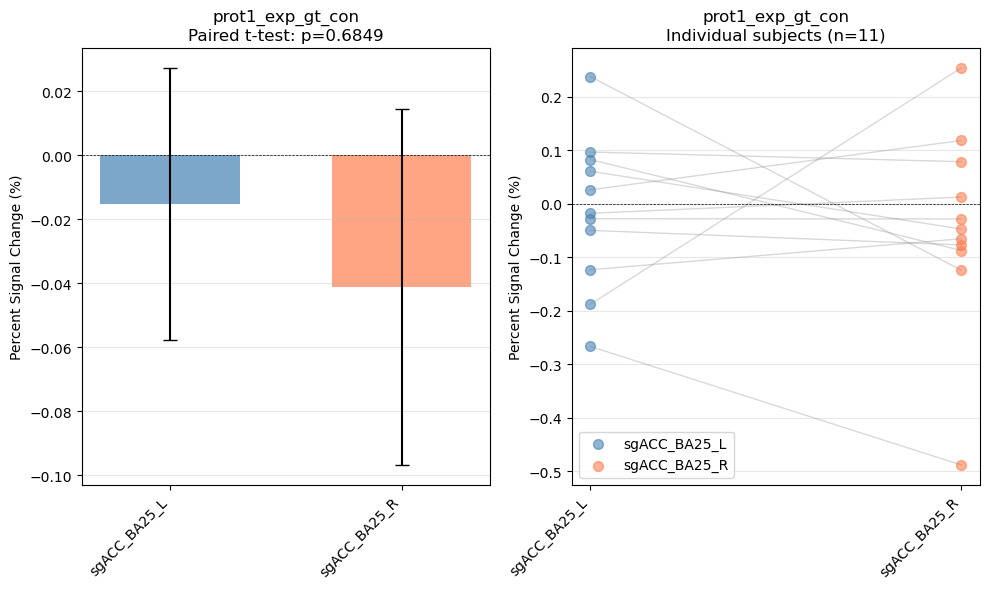

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot2_exp_gt_con.png


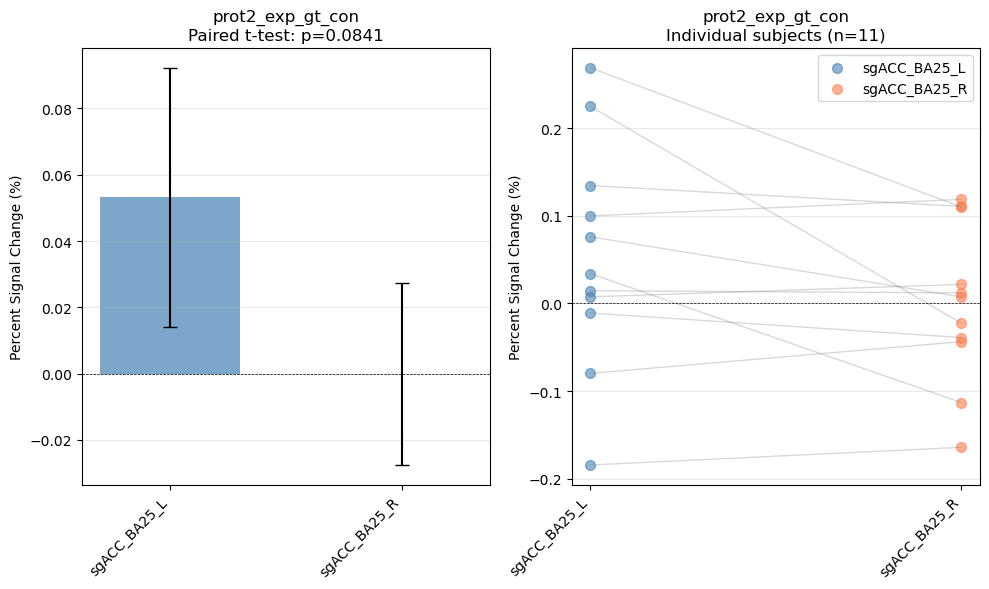

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot3_exp_gt_con.png


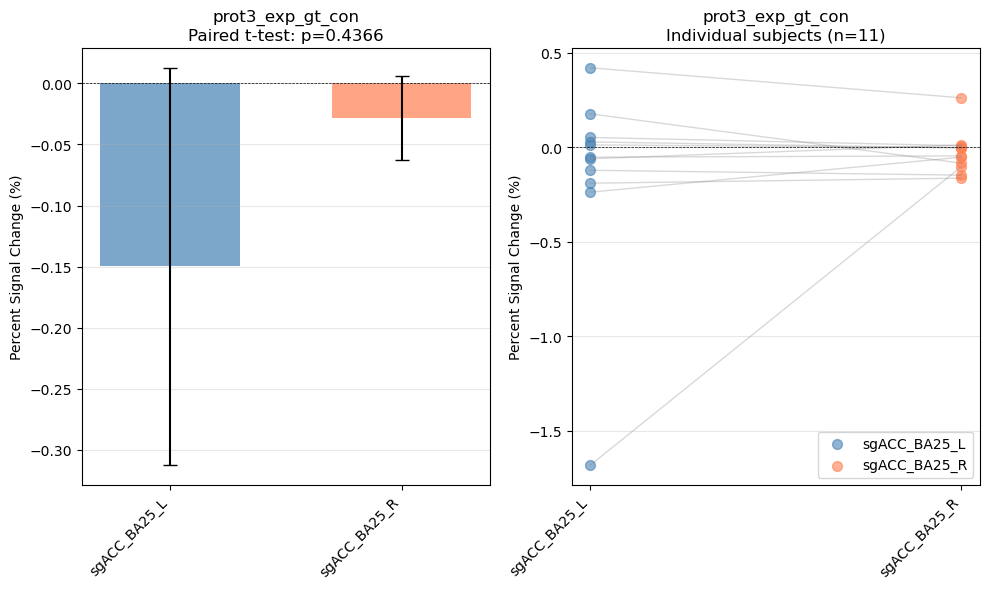

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot4_exp_gt_con.png


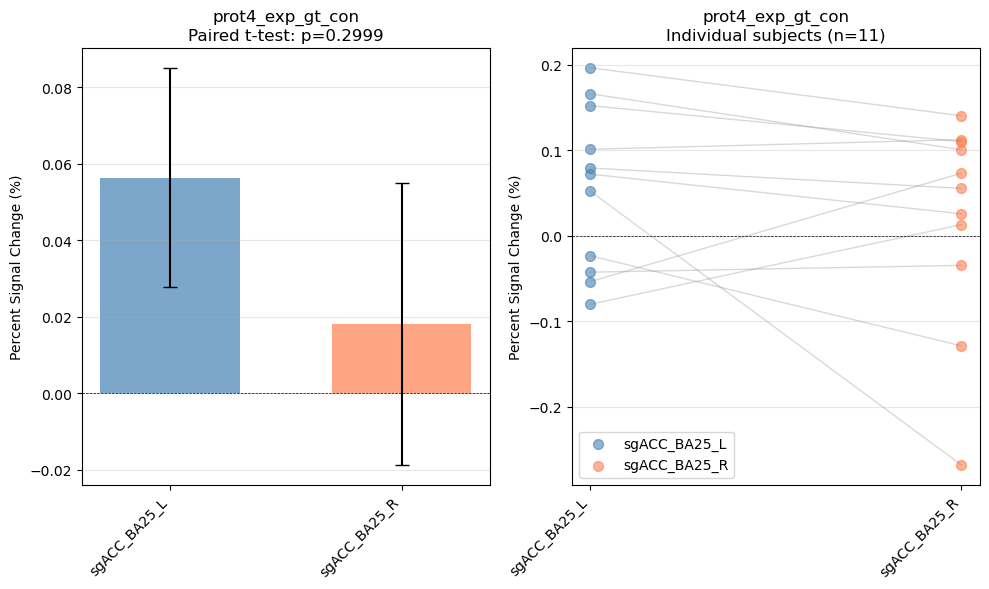


[OK] Saved hemisphere comparison results to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_results.csv


,contrast,left_roi,right_roi,n_subjects,left_mean,right_mean,left_sem,right_sem,t_statistic,p_value,test
0,prot1_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,-0.015219,-0.041107,0.042591,0.055674,0.417793,0.684927,Paired t-test
1,prot2_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,0.053240,-0.000128,0.039021,0.027431,1.917562,0.084147,Paired t-test
2,prot3_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,-0.149817,-0.028331,0.162561,0.034445,-0.810378,0.436583,Paired t-test
3,prot4_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,0.056399,0.018169,0.028698,0.036932,1.093239,0.299924,Paired t-test


In [20]:
# Compare left vs right ROIs for each protocol's exp > con contrast
if not roi_data_all.empty and hemisphere_pairs:
    hemisphere_comparison_results = []
    
    for base_name, (left_roi, right_roi) in hemisphere_pairs.items():
        print(f"\n{'='*80}")
        print(f"Comparing {left_roi} vs {right_roi}")
        print(f"{'='*80}")
        
        for prot in ['prot1', 'prot2', 'prot3', 'prot4']:
            contrast_name = f'{prot}_exp_gt_con'
            
            if contrast_name in roi_data_all['contrast'].values:
                result = compare_hemispheres(
                    roi_data_all,
                    left_roi,
                    right_roi,
                    contrast_name,
                    test='paired',
                    save_path=roi_dir / f'hemisphere_comparison_{base_name}_{prot}_exp_gt_con.png'
                )
                
                if result:
                    hemisphere_comparison_results.append(result)
    
    # Save comparison results
    if hemisphere_comparison_results:
        comparison_df = pd.DataFrame(hemisphere_comparison_results)
        comparison_csv = roi_dir / 'hemisphere_comparison_results.csv'
        comparison_df.to_csv(comparison_csv, index=False)
        print(f"\n[OK] Saved hemisphere comparison results to: {comparison_csv}")
        display(comparison_df)
else:
    print("No ROI data available or no hemisphere pairs found.")


### Plot exp > baseline and con > baseline grouped by ROI

This creates a grouped plot where for each ROI, exp > baseline and con > baseline are shown side by side.


Plotting exp > baseline and con > baseline for: ['sgACC_BA25_L', 'sgACC_BA25_R']
Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_prot1.png


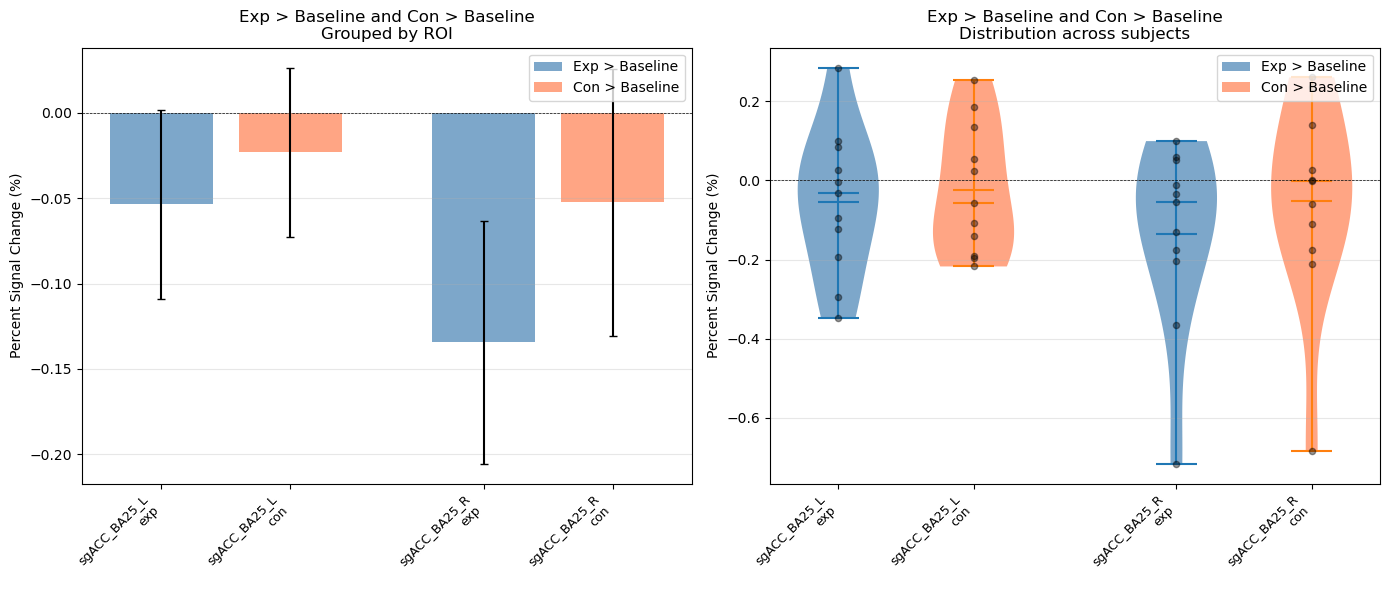

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_prot2.png


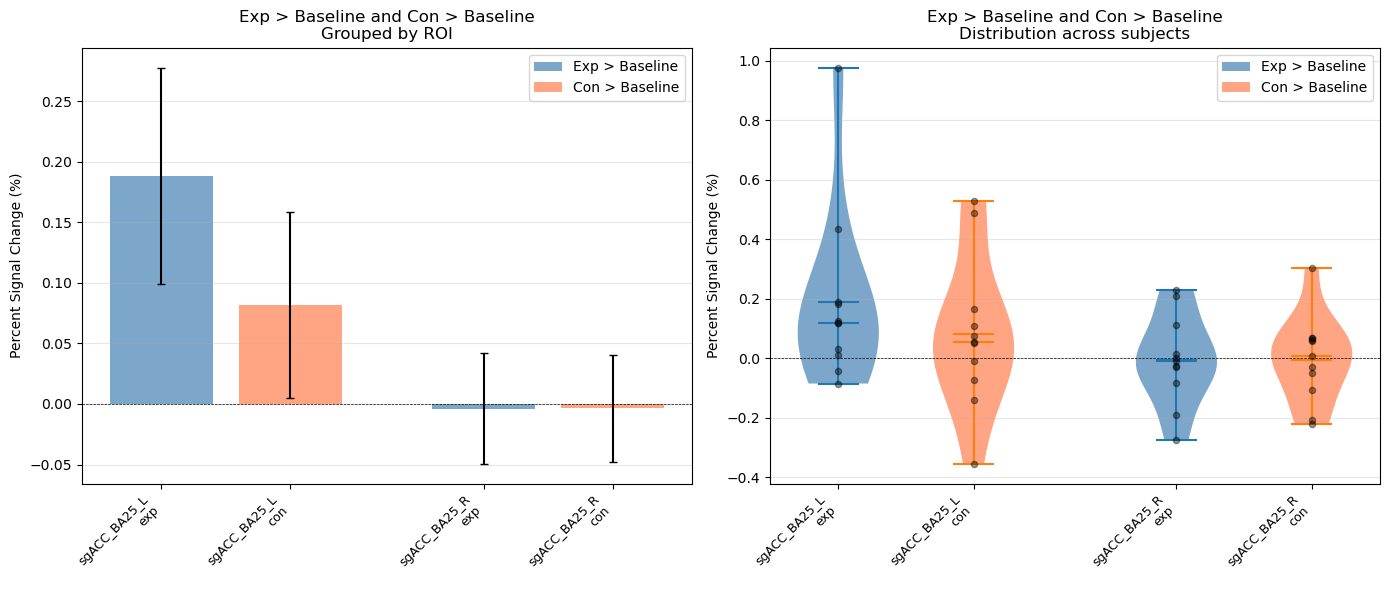

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_prot3.png


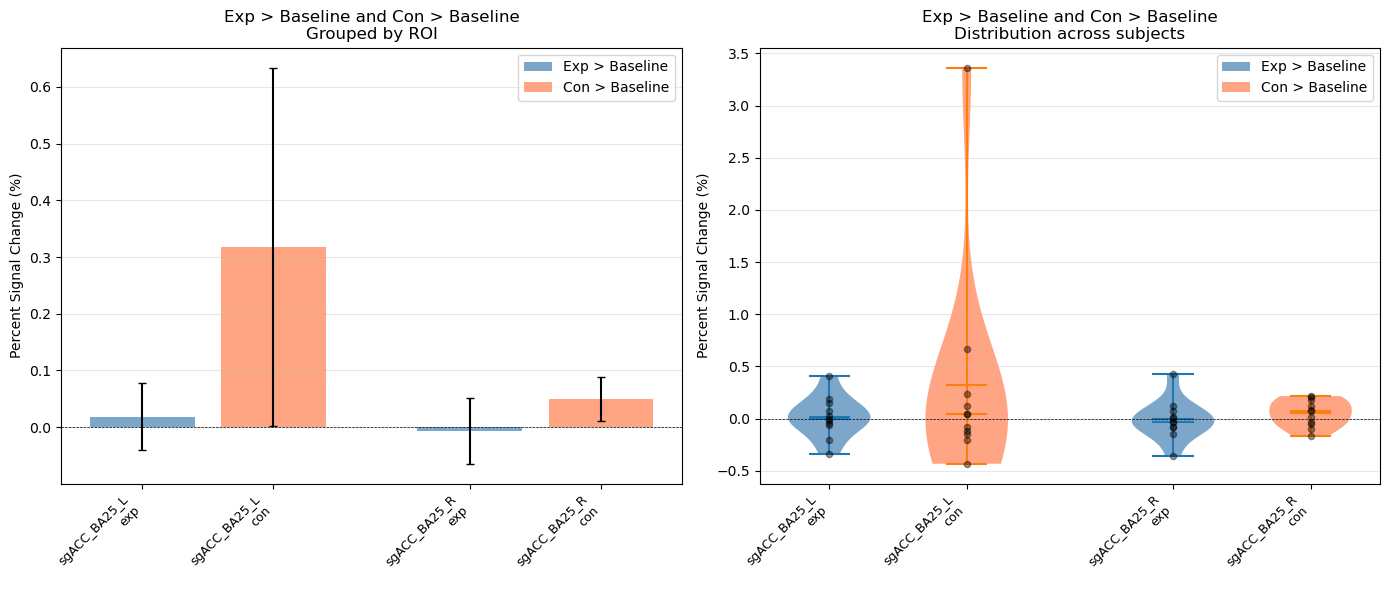

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_prot4.png


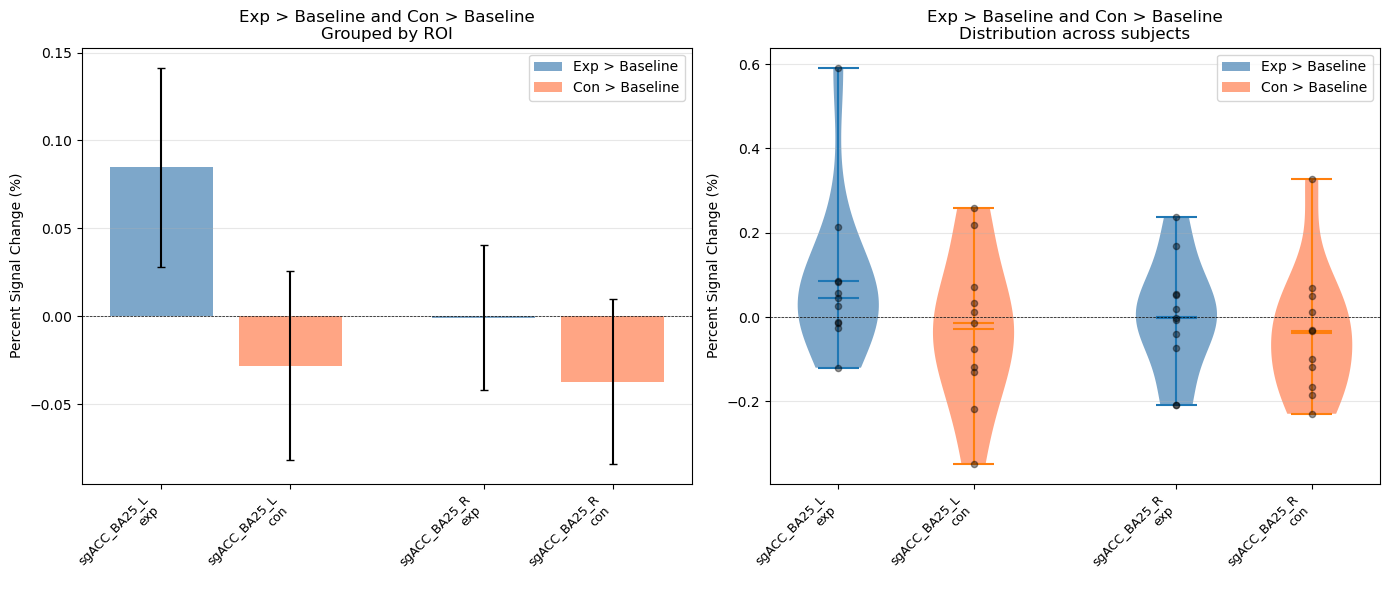

In [21]:
# Plot exp > baseline and con > baseline grouped for selected ROIs
if not roi_data_all.empty:
    # Select ROIs to plot (e.g., sgACC ROIs)
    # selected_rois = select_rois(pattern='sgACC')
    selected_rois = ['sgACC_BA25_L', 'sgACC_BA25_R']
    
    if selected_rois:
        print(f"Plotting exp > baseline and con > baseline for: {selected_rois}")
        
        # Plot for each protocol separately, or combine all protocols
        # Option 1: Plot all protocols together
        # plot_exp_con_baseline_grouped(
        #    roi_data_all,
        #    selected_rois,
        #    protocols=['prot1', 'prot2', 'prot3', 'prot4'],
        #    save_path=roi_dir / 'exp_con_baseline_grouped_all_protocols.png'
        #)
        
        # Option 2: Plot each protocol separately (uncomment to use)
        for prot in ['prot1', 'prot2', 'prot3', 'prot4']:
            plot_exp_con_baseline_grouped(
                roi_data_all,
                selected_rois,                
                protocols=[prot],
                save_path=roi_dir / f'exp_con_baseline_grouped_{prot}.png'
            )
    else:
        print("No ROIs selected. Use select_rois() to choose ROIs to plot.")
else:
    print("No ROI data available.")


### Custom ROI selection and plotting

You can customize which ROIs to plot and which protocols to include.


Custom ROIs selected: ['sgACC_BA25_L', 'sgACC_BA25_R']
Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_custom.png


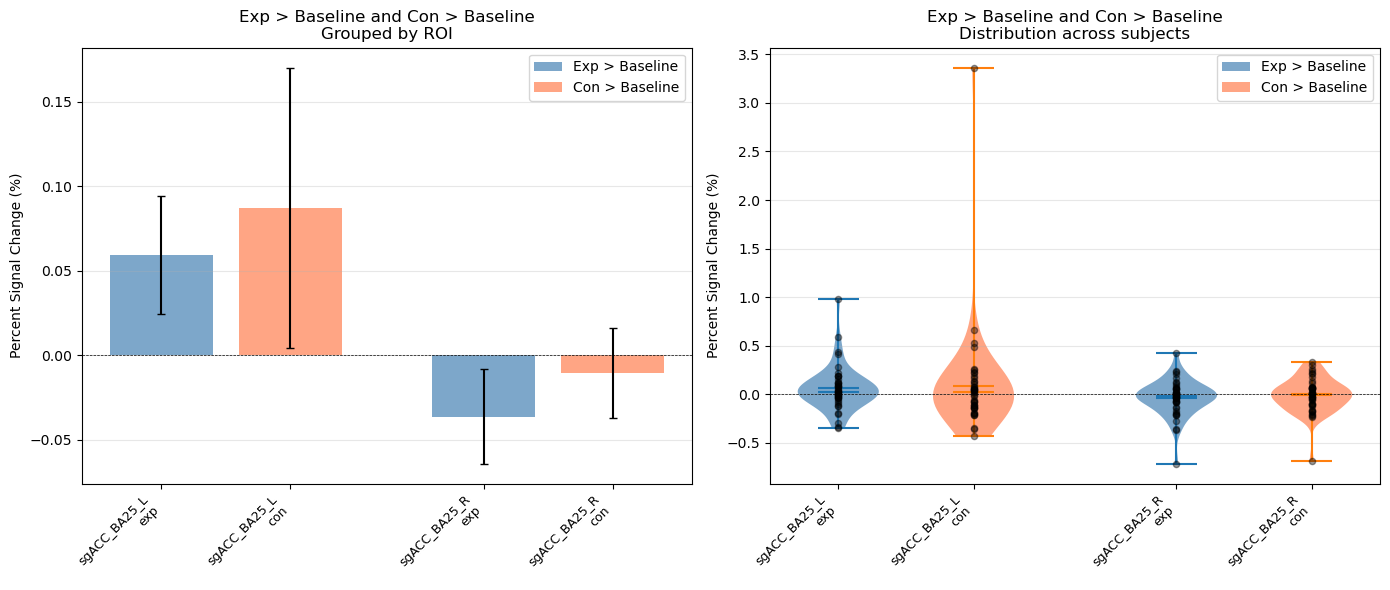

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_exp_gt_con_overall.png


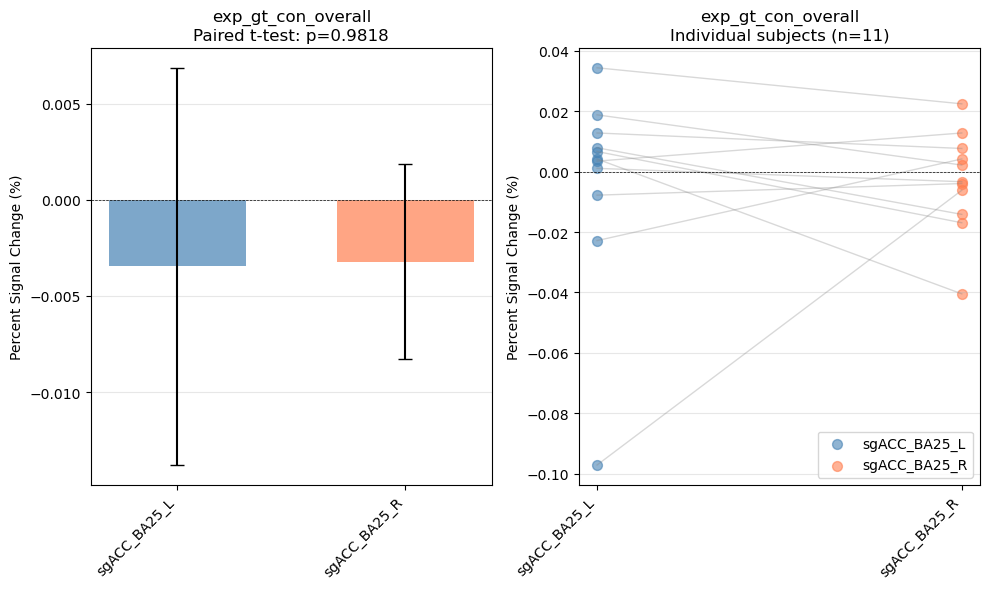

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot1_exp_gt_con.png


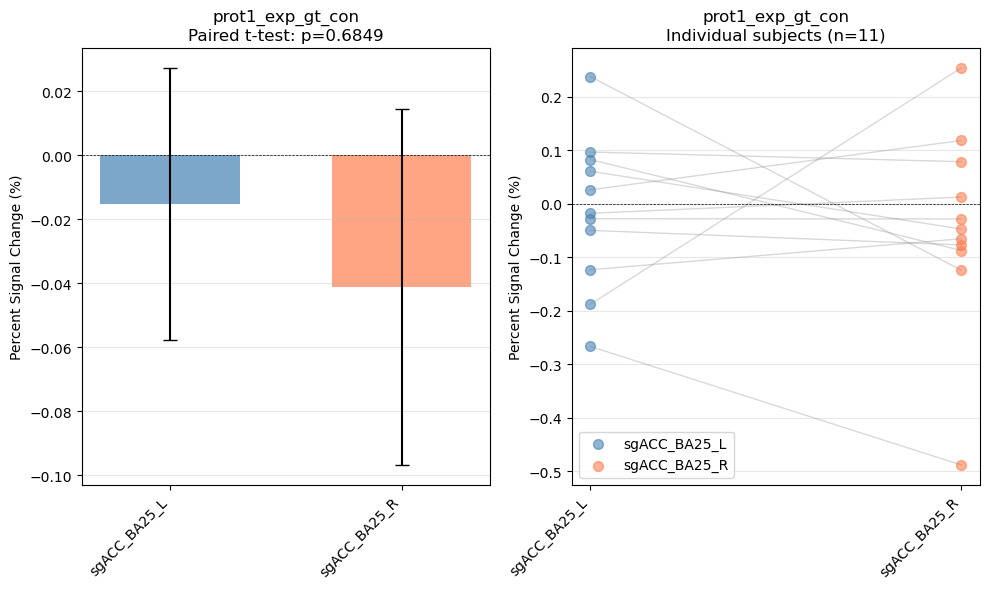

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot2_exp_gt_con.png


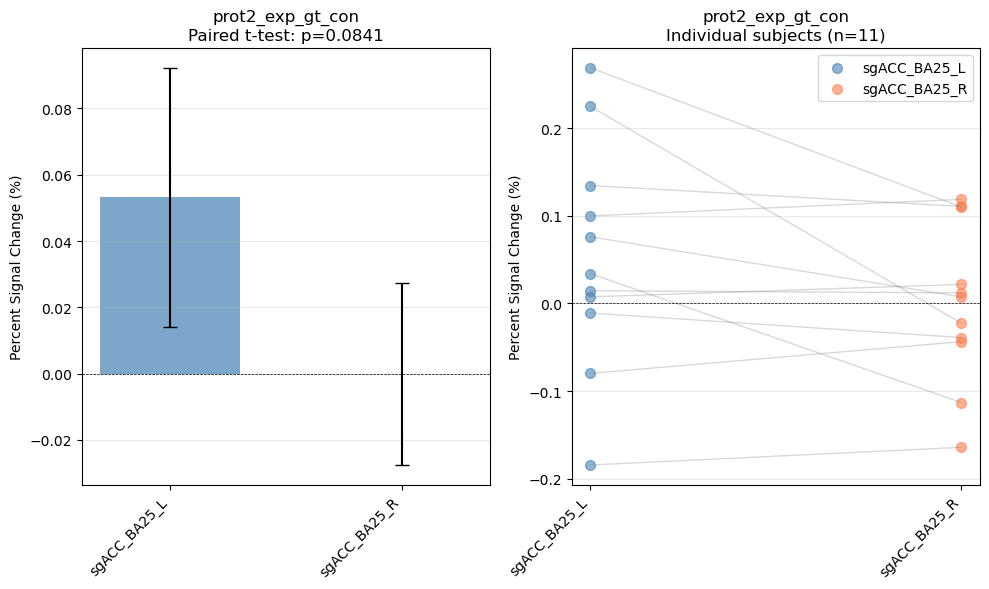

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot3_exp_gt_con.png


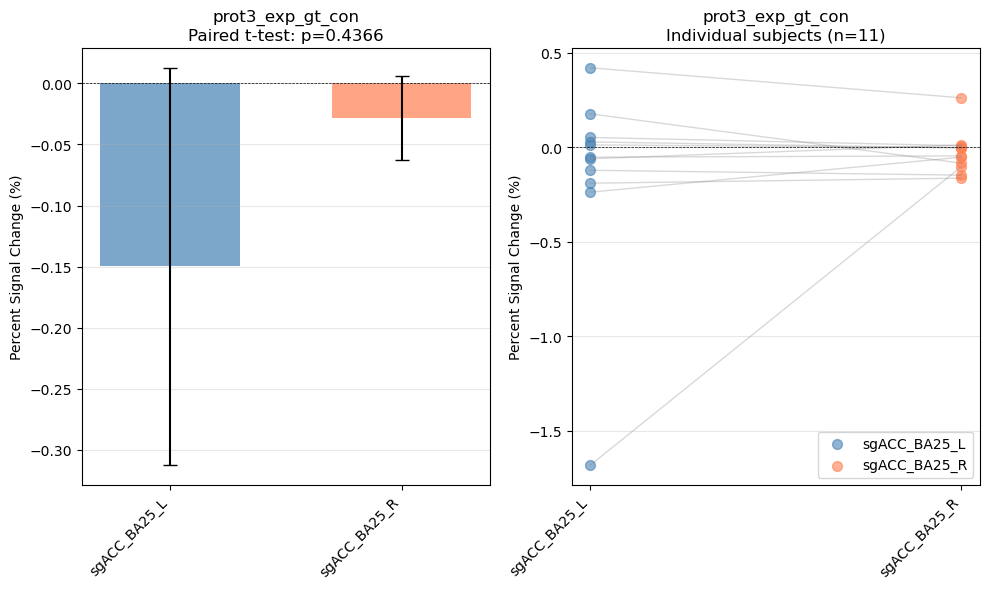

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot4_exp_gt_con.png


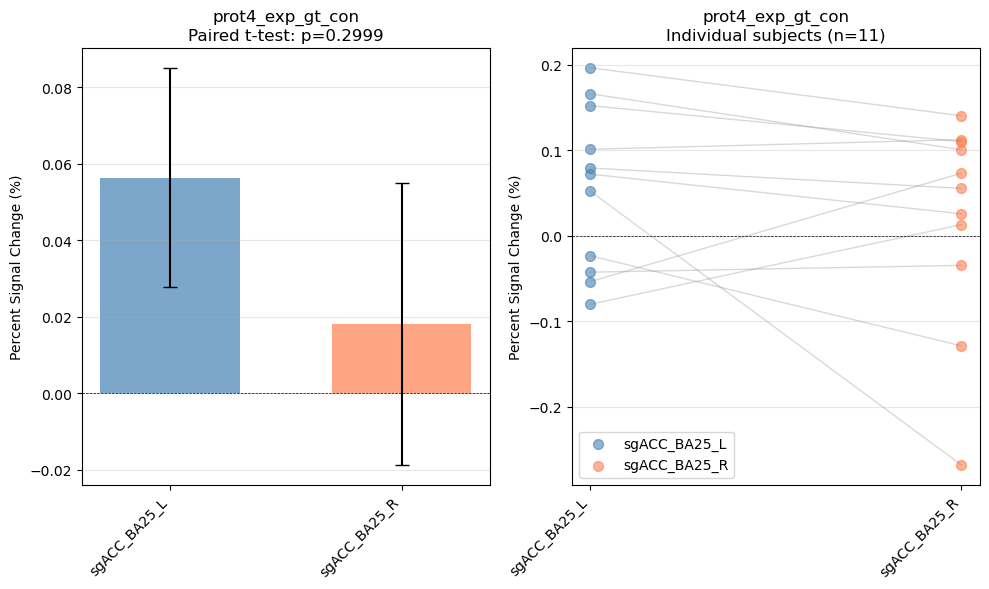


[OK] Saved hemisphere comparison results to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_custom_contrasts.csv


,contrast,left_roi,right_roi,n_subjects,left_mean,right_mean,left_sem,right_sem,t_statistic,p_value,test
0,exp_gt_con_overall,sgACC_BA25_L,sgACC_BA25_R,11,-0.003462,-0.003212,0.010328,0.005068,-0.023342,0.981836,Paired t-test
1,prot1_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,-0.015219,-0.041107,0.042591,0.055674,0.417793,0.684927,Paired t-test
2,prot2_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,0.053240,-0.000128,0.039021,0.027431,1.917562,0.084147,Paired t-test
3,prot3_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,-0.149817,-0.028331,0.162561,0.034445,-0.810378,0.436583,Paired t-test
4,prot4_exp_gt_con,sgACC_BA25_L,sgACC_BA25_R,11,0.056399,0.018169,0.028698,0.036932,1.093239,0.299924,Paired t-test


In [22]:
# --- Flexible hemisphere comparison for custom contrasts ---
def run_hemisphere_comparisons(
    roi_data,
    hemisphere_pairs,
    contrasts=None,              # list[str] or callable or None
    pair_bases=None,             # list[str] of base_names to include, or None for all
    test="paired",
    roi_dir=None,
    fname_prefix="hemisphere_comparison",
    max_pairs=None,              # e.g. 1 to mimic your previous example
):
    """
    Compare left vs right ROIs for a set of contrasts.

    Parameters
    ----------
    roi_data : pd.DataFrame
        Must contain columns: subject, contrast, roi_name, percent_signal_change
    hemisphere_pairs : dict
        base_name -> (left_roi, right_roi)
    contrasts : list[str] | callable | None
        - list[str]: explicit contrasts to test/plot
        - callable: function taking roi_data -> list[str]
        - None: uses all contrasts available in roi_data
    pair_bases : list[str] | None
        Limit to specific base ROI names (keys of hemisphere_pairs).
    test : str
        'paired' or 'independent'
    roi_dir : Path | None
        If provided, saves figures into roi_dir.
    fname_prefix : str
        Prefix for saved figure names.
    max_pairs : int | None
        Limit number of hemisphere pairs processed (useful for quick checks).
    """
    if roi_data is None or roi_data.empty:
        print("No ROI data available.")
        return pd.DataFrame()

    if not hemisphere_pairs:
        print("No hemisphere pairs found.")
        return pd.DataFrame()

    # Determine contrasts to run
    if contrasts is None:
        contrast_list = sorted(roi_data["contrast"].dropna().unique().tolist())
    elif callable(contrasts):
        contrast_list = list(contrasts(roi_data))
    else:
        contrast_list = list(contrasts)

    # Keep only contrasts that actually exist in roi_data
    available = set(roi_data["contrast"].dropna().unique().tolist())
    contrast_list = [c for c in contrast_list if c in available]

    if not contrast_list:
        print("No requested contrasts are available in roi_data.")
        return pd.DataFrame()

    # Determine pairs to run
    bases = list(hemisphere_pairs.keys())
    if pair_bases is not None:
        bases = [b for b in bases if b in set(pair_bases)]

    bases = sorted(bases)
    if max_pairs is not None:
        bases = bases[: int(max_pairs)]

    results = []

    for base_name in bases:
        left_roi, right_roi = hemisphere_pairs[base_name]

        for contrast_name in contrast_list:
            out_png = None
            if roi_dir is not None:
                out_png = roi_dir / f"{fname_prefix}_{base_name}_{contrast_name}.png"

            result = compare_hemispheres(
                roi_data,
                left_roi,
                right_roi,
                contrast_name,
                test=test,
                save_path=out_png,
            )

            if result:
                results.append(result)

    results_df = pd.DataFrame(results)
    return results_df


# =========================
# Example: Custom ROI selection and plotting
# =========================
if not roi_data_all.empty:
    custom_rois = ['sgACC_BA25_L', 'sgACC_BA25_R']

    if custom_rois:
        print(f"Custom ROIs selected: {custom_rois}")

        plot_exp_con_baseline_grouped(
            roi_data_all,
            custom_rois,
            protocols=['prot1', 'prot2', 'prot3', 'prot4'],
            save_path=roi_dir / 'exp_con_baseline_grouped_custom.png'
        )
    else:
        print("No ROIs match the selection criteria.")

    # --- Flexible: choose any contrasts you want here ---
    custom_contrasts = [
        "exp_gt_con_overall",
        "prot1_exp_gt_con",
        "prot2_exp_gt_con",
        "prot3_exp_gt_con",
        "prot4_exp_gt_con",
    ]

    if hemisphere_pairs:
        hemi_results = run_hemisphere_comparisons(
            roi_data=roi_data_all,
            hemisphere_pairs=hemisphere_pairs,
            contrasts=custom_contrasts,          # <- change this anytime
            pair_bases=None,                     # or e.g. ["sgACC_anat"]
            test="paired",
            roi_dir=roi_dir,
            fname_prefix="hemisphere_comparison",
            max_pairs=None,                      # set to 1 for quick test
        )

        if not hemi_results.empty:
            out_csv = roi_dir / "hemisphere_comparison_custom_contrasts.csv"
            hemi_results.to_csv(out_csv, index=False)
            print(f"\n[OK] Saved hemisphere comparison results to: {out_csv}")
            display(hemi_results)
        else:
            print("No hemisphere comparison results produced (missing data?).")
else:
    print("No ROI data available.")


Custom ROIs selected: ['sgACC_BA25_L', 'sgACC_BA25_R']
Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_custom.png


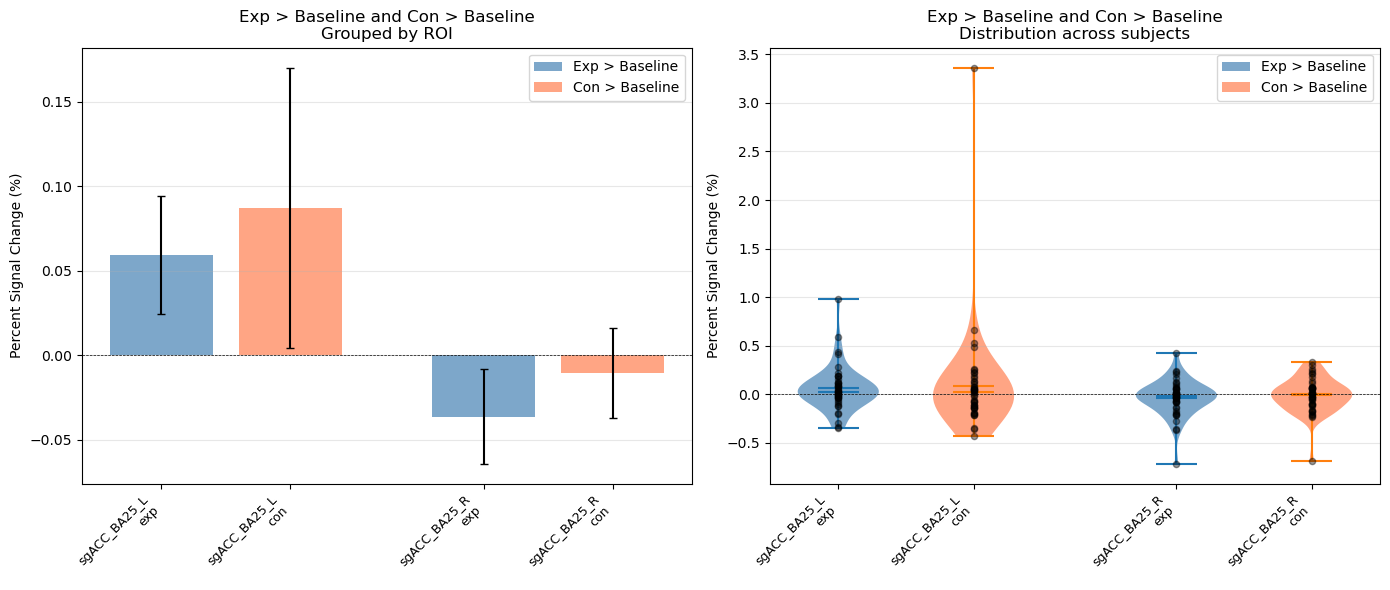

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot1_exp_gt_baseline.png


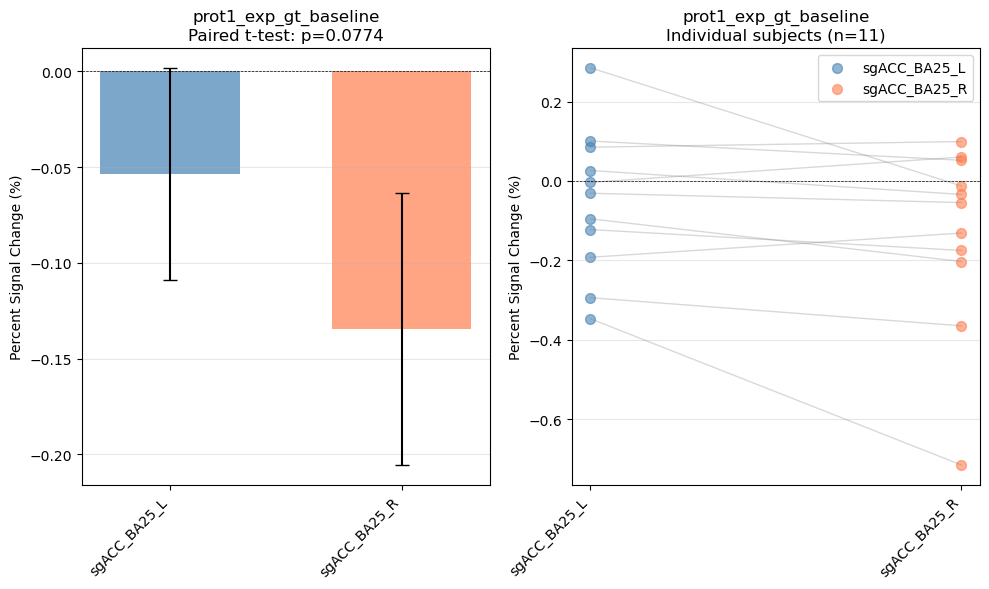

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot2_exp_gt_baseline.png


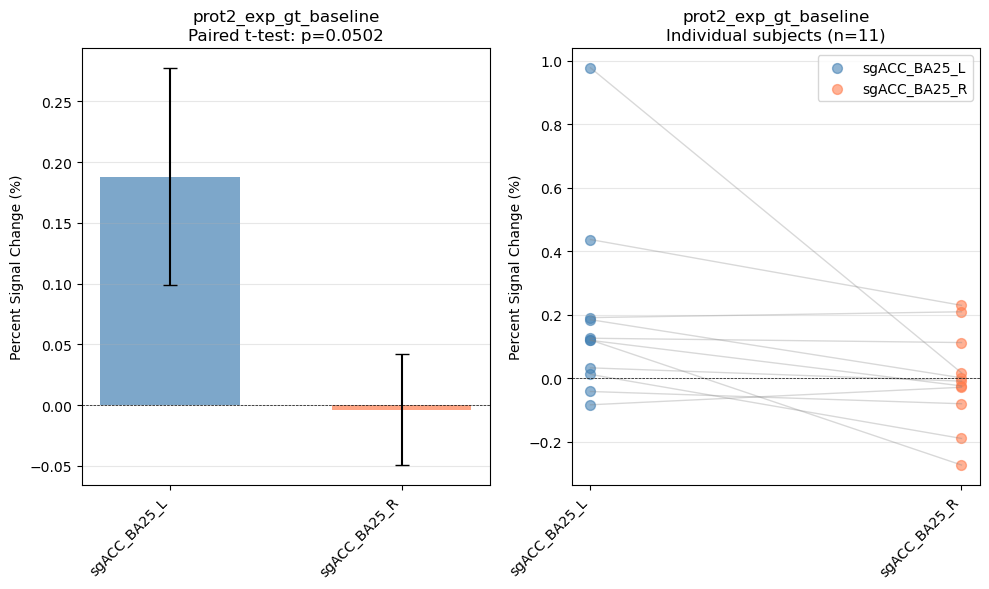

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot3_exp_gt_baseline.png


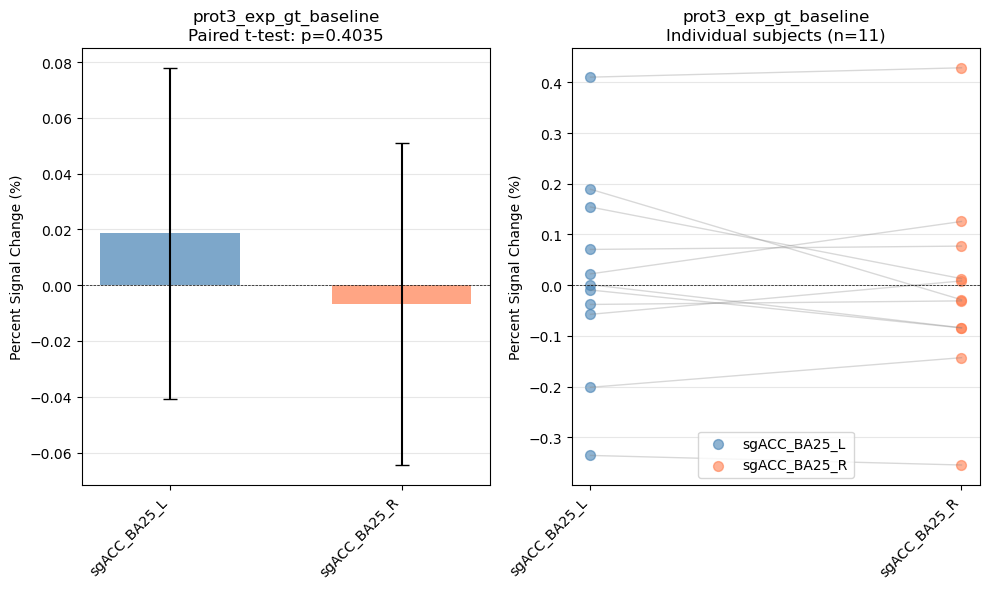

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot4_exp_gt_baseline.png


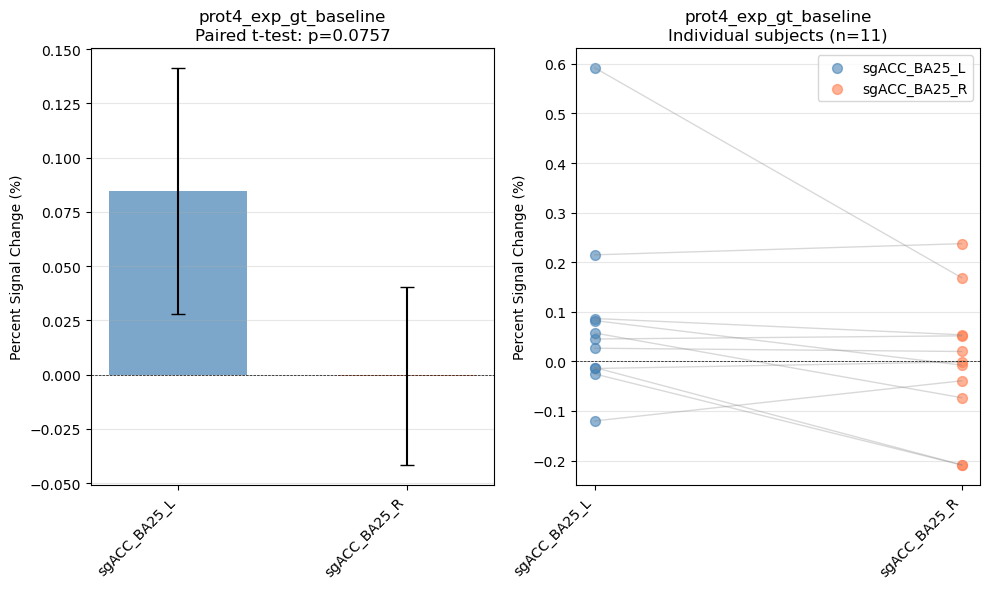


[OK] Saved hemisphere comparison results to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_custom_contrasts.csv


,contrast,left_roi,right_roi,n_subjects,left_mean,right_mean,left_sem,right_sem,t_statistic,p_value,test
0,prot1_exp_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,-0.053463,-0.134456,0.055356,0.071110,1.967778,0.077430,Paired t-test
1,prot2_exp_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,0.188188,-0.003796,0.089519,0.045549,2.225451,0.050228,Paired t-test
2,prot3_exp_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,0.018600,-0.006679,0.059357,0.057789,0.872308,0.403499,Paired t-test
3,prot4_exp_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,0.084774,-0.000676,0.056681,0.040999,1.981453,0.075690,Paired t-test


In [23]:
if not roi_data_all.empty:
    custom_rois = ['sgACC_BA25_L', 'sgACC_BA25_R']

    if custom_rois:
        print(f"Custom ROIs selected: {custom_rois}")

        plot_exp_con_baseline_grouped(
            roi_data_all,
            custom_rois,
            protocols=['prot1', 'prot2', 'prot3', 'prot4'],
            save_path=roi_dir / 'exp_con_baseline_grouped_custom.png'
        )
    else:
        print("No ROIs match the selection criteria.")

    # --- Flexible: choose any contrasts you want here ---
    custom_contrasts = [        
        "prot1_exp_gt_baseline",
        "prot2_exp_gt_baseline",
        "prot3_exp_gt_baseline",
        "prot4_exp_gt_baseline",
    ]

    if hemisphere_pairs:
        hemi_results = run_hemisphere_comparisons(
            roi_data=roi_data_all,
            hemisphere_pairs=hemisphere_pairs,
            contrasts=custom_contrasts,          # <- change this anytime
            pair_bases=None,                     # or e.g. ["sgACC_anat"]
            test="paired",
            roi_dir=roi_dir,
            fname_prefix="hemisphere_comparison",
            max_pairs=None,                      # set to 1 for quick test
        )

        if not hemi_results.empty:
            out_csv = roi_dir / "hemisphere_comparison_custom_contrasts.csv"
            hemi_results.to_csv(out_csv, index=False)
            print(f"\n[OK] Saved hemisphere comparison results to: {out_csv}")
            display(hemi_results)
        else:
            print("No hemisphere comparison results produced (missing data?).")
else:
    print("No ROI data available.")

Custom ROIs selected: ['sgACC_BA25_L', 'sgACC_BA25_R']
Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/exp_con_baseline_grouped_custom.png


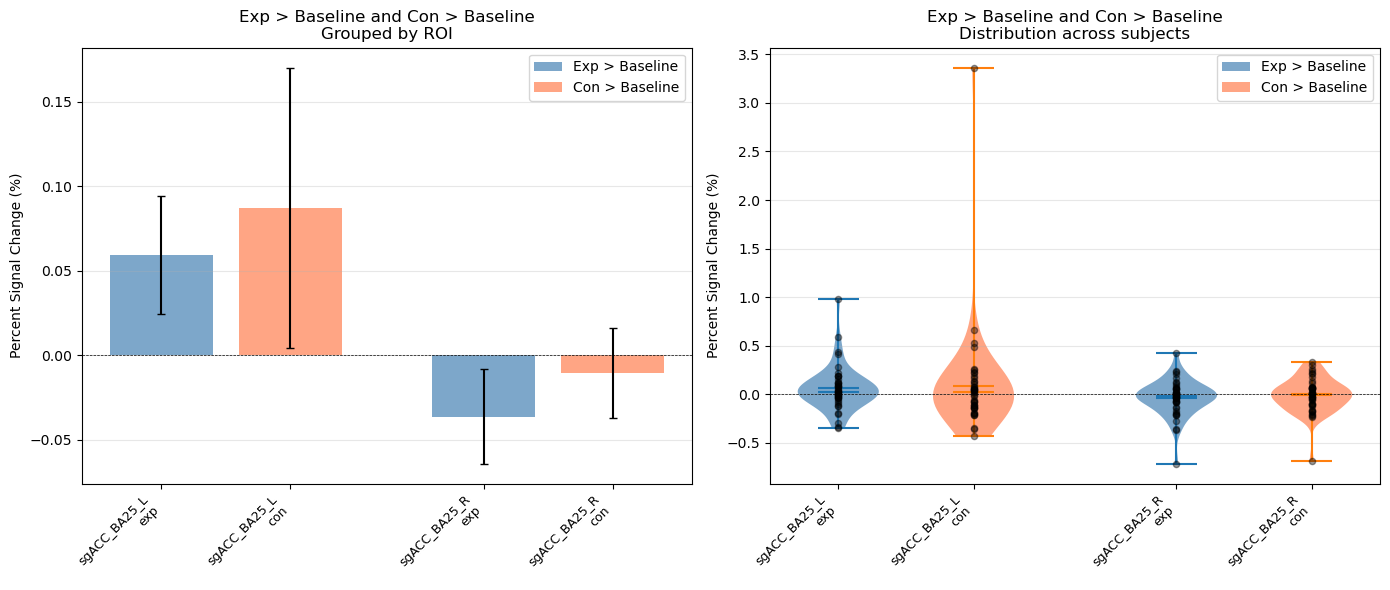

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot1_con_gt_baseline.png


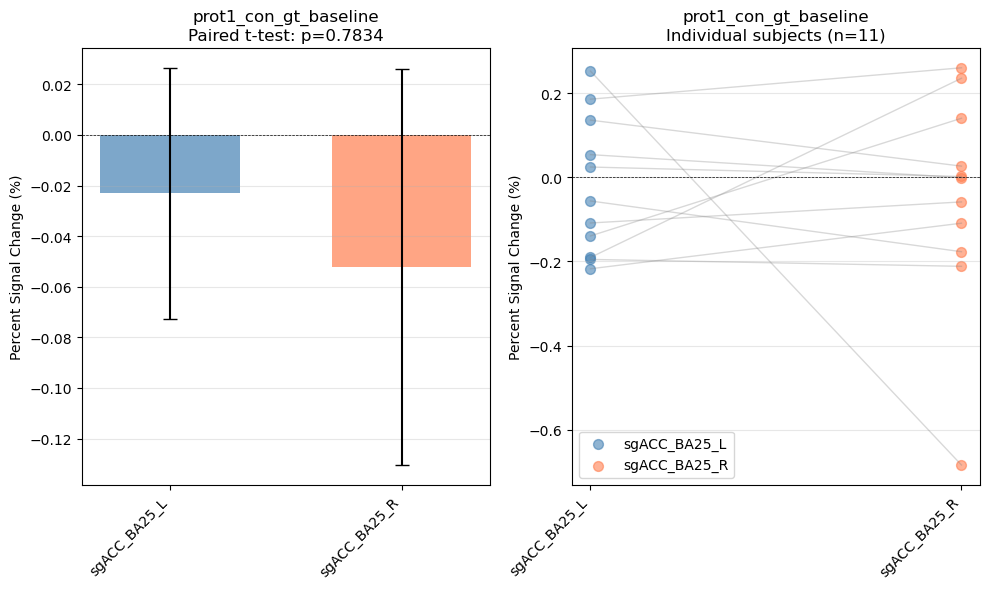

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot2_con_gt_baseline.png


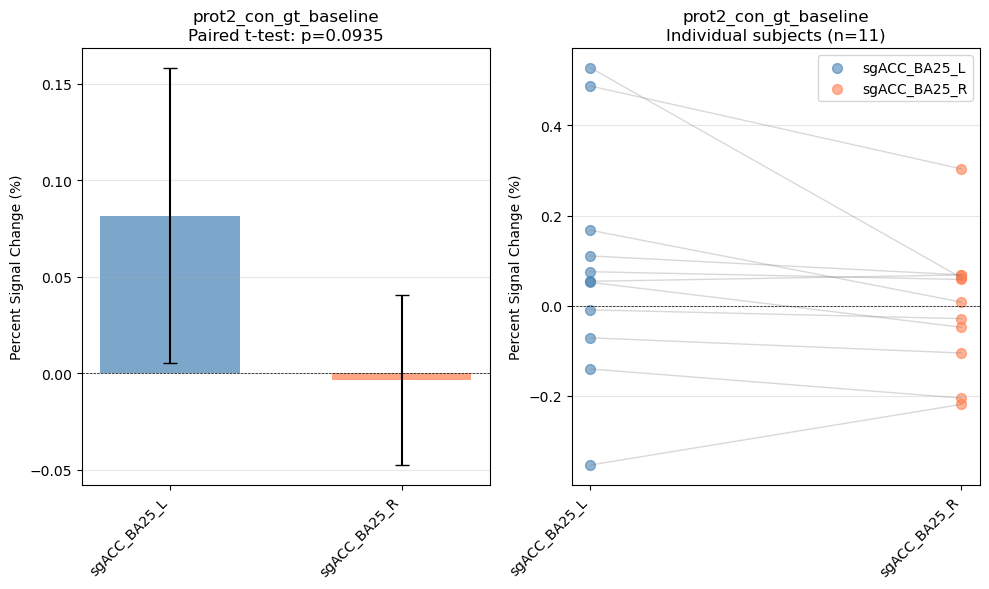

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot3_con_gt_baseline.png


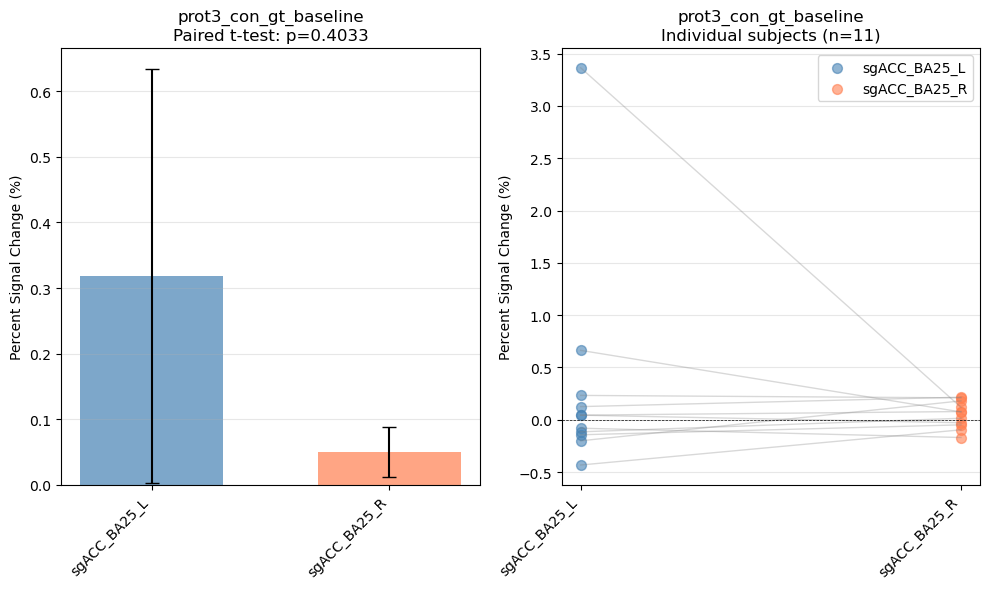

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_sgACC_BA25_prot4_con_gt_baseline.png


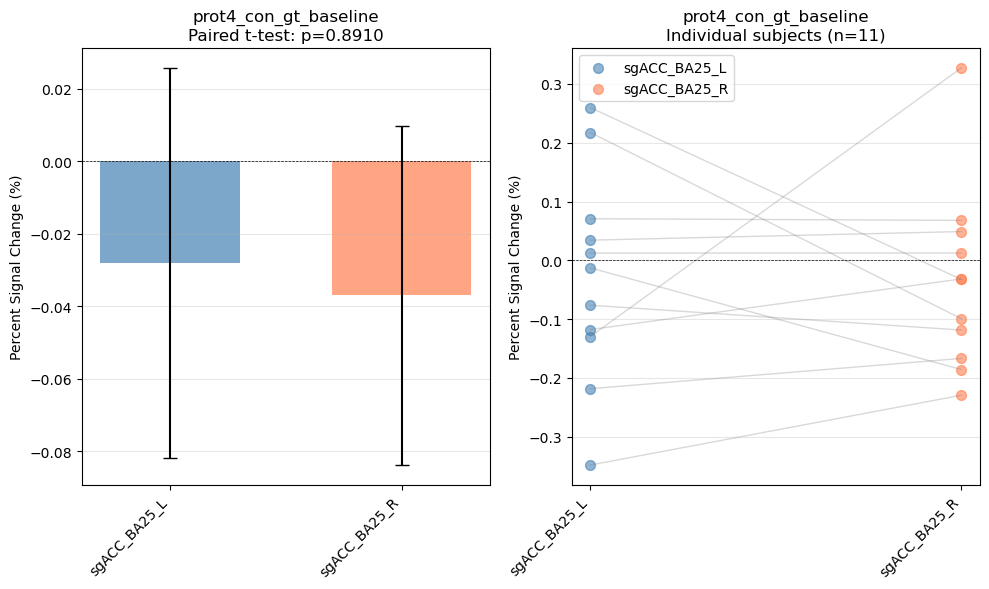


[OK] Saved hemisphere comparison results to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/hemisphere_comparison_custom_contrasts.csv


,contrast,left_roi,right_roi,n_subjects,left_mean,right_mean,left_sem,right_sem,t_statistic,p_value,test
0,prot1_con_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,-0.023025,-0.052242,0.049573,0.078196,0.282428,0.783375,Paired t-test
1,prot2_con_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,0.081709,-0.003540,0.076552,0.044000,1.853488,0.093509,Paired t-test
2,prot3_con_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,0.318234,0.049983,0.316009,0.038499,0.872715,0.403287,Paired t-test
3,prot4_con_gt_baseline,sgACC_BA25_L,sgACC_BA25_R,11,-0.028024,-0.037014,0.053750,0.046733,0.140607,0.890973,Paired t-test


In [24]:
if not roi_data_all.empty:
    custom_rois = ['sgACC_BA25_L', 'sgACC_BA25_R']

    if custom_rois:
        print(f"Custom ROIs selected: {custom_rois}")

        plot_exp_con_baseline_grouped(
            roi_data_all,
            custom_rois,
            protocols=['prot1', 'prot2', 'prot3', 'prot4'],
            save_path=roi_dir / 'exp_con_baseline_grouped_custom.png'
        )
    else:
        print("No ROIs match the selection criteria.")

    # --- Flexible: choose any contrasts you want here ---
    custom_contrasts = [        
        "prot1_con_gt_baseline",
        "prot2_con_gt_baseline",
        "prot3_con_gt_baseline",
        "prot4_con_gt_baseline",
    ]

    if hemisphere_pairs:
        hemi_results = run_hemisphere_comparisons(
            roi_data=roi_data_all,
            hemisphere_pairs=hemisphere_pairs,
            contrasts=custom_contrasts,          # <- change this anytime
            pair_bases=None,                     # or e.g. ["sgACC_anat"]
            test="paired",
            roi_dir=roi_dir,
            fname_prefix="hemisphere_comparison",
            max_pairs=None,                      # set to 1 for quick test
        )

        if not hemi_results.empty:
            out_csv = roi_dir / "hemisphere_comparison_custom_contrasts.csv"
            hemi_results.to_csv(out_csv, index=False)
            print(f"\n[OK] Saved hemisphere comparison results to: {out_csv}")
            display(hemi_results)
        else:
            print("No hemisphere comparison results produced (missing data?).")
else:
    print("No ROI data available.")

Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/raincloud_exp_gt_con_L_sgACC.png


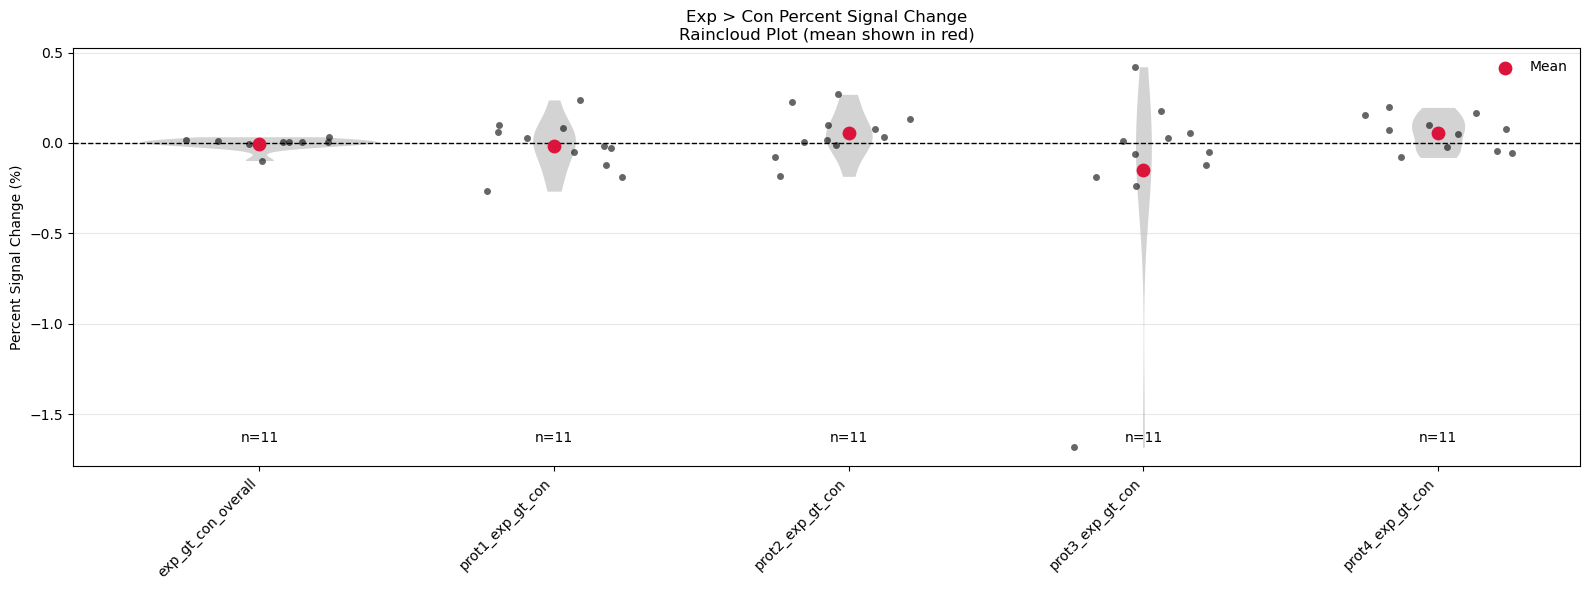

In [25]:
def get_exp_gt_con_contrasts(roi_data):
    """
    Return sorted list of contrasts containing 'exp_gt_con'.
    """
    return sorted(
        c for c in roi_data["contrast"].unique()
        if "exp_gt_con" in c
    )

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_exp_gt_con_raincloud(
    roi_data,
    roi_names,
    contrasts=None,
    figsize=(14, 6),
    save_path=None,
):
    """
    Raincloud-style plot for exp > con PSC values.
    
    Parameters
    ----------
    roi_data : pd.DataFrame
        Must contain columns:
        subject, contrast, roi_name, percent_signal_change
    roi_names : list[str]
        ROIs to include
    contrasts : list[str] or None
        Contrasts to plot (default: all exp_gt_con*)
    figsize : tuple
        Figure size
    save_path : Path or None
        Save figure if provided
    """
    df = roi_data[
        roi_data["roi_name"].isin(roi_names)
    ].copy()

    if contrasts is None:
        contrasts = get_exp_gt_con_contrasts(df)

    df = df[df["contrast"].isin(contrasts)]

    if df.empty:
        print("No exp > con data found for selected ROIs.")
        return

    # Order contrasts nicely
    order = contrasts

    # Compute n per contrast (unique subjects)
    n_per_contrast = (
        df.groupby("contrast")["subject"]
        .nunique()
        .reindex(order)
    )

    plt.figure(figsize=figsize)

    # --- Violin (distribution) ---
    sns.violinplot(
        data=df,
        x="contrast",
        y="percent_signal_change",
        order=order,
        inner=None,
        cut=0,
        linewidth=0,
        color="lightgray",
    )

    # --- Strip (rain) ---
    sns.stripplot(
        data=df,
        x="contrast",
        y="percent_signal_change",
        order=order,
        color="black",
        alpha=0.6,
        size=5,
        jitter=0.25,
    )

    # --- Mean marker ---
    means = (
        df.groupby("contrast")["percent_signal_change"]
        .mean()
        .reindex(order)
    )

    plt.scatter(
        range(len(order)),
        means,
        color="crimson",
        s=80,
        zorder=10,
        label="Mean",
    )

    # --- Annotate n ---
    y_min, y_max = plt.ylim()
    y_text = y_min + 0.05 * (y_max - y_min)

    for i, (contrast, n) in enumerate(n_per_contrast.items()):
        plt.text(
            i,
            y_text,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.ylabel("Percent Signal Change (%)")
    plt.xlabel("")
    plt.title("Exp > Con Percent Signal Change\nRaincloud Plot (mean shown in red)")
    plt.legend(frameon=False)
    plt.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()

if not roi_data_all.empty:
    plot_exp_gt_con_raincloud(
        roi_data=roi_data_all,
        roi_names=["sgACC_BA25_L"],
        contrasts=None,  # automatically uses all exp_gt_con*
        figsize=(16, 6),
        save_path=roi_dir / "raincloud_exp_gt_con_L_sgACC.png",
    )



In [26]:
import matplotlib.pyplot as plt
import numpy as np

def plot_exp_gt_con_bar_pretty(
    roi_data,
    roi_names,
    contrasts=None,
    figsize=(6, 4),
    save_path=None,
    jitter=0.12,     # horizontal jitter width
):
    df = roi_data[roi_data["roi_name"].isin(roi_names)].copy()

    if contrasts is None:
        contrasts = [
            "exp_gt_con_overall",
            "prot1_exp_gt_con",
            "prot2_exp_gt_con",
            "prot3_exp_gt_con",
            "prot4_exp_gt_con",
        ]

    df = df[df["contrast"].isin(contrasts)]

    if df.empty:
        print("No exp > con data found.")
        return

    # Summary stats
    summary = (
        df.groupby("contrast")
        .agg(
            mean_psc=("percent_signal_change", "mean"),
            sem_psc=("percent_signal_change", lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
            n=("subject", "nunique"),
        )
        .reindex(contrasts)
    )

    # Clean x-labels
    label_map = {
        "exp_gt_con_overall": "Overall",
        "prot1_exp_gt_con": "Prot 1",
        "prot2_exp_gt_con": "Prot 2",
        "prot3_exp_gt_con": "Prot 3",
        "prot4_exp_gt_con": "Prot 4",
    }
    x_labels = [label_map[c] for c in summary.index]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(summary))

    # Bars
    ax.bar(
        x,
        summary["mean_psc"],
        yerr=summary["sem_psc"],
        capsize=5,
        color="#4C72B0",
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        zorder=1,
    )

    # --- Individual subject points (jittered) ---
    for i, contrast in enumerate(summary.index):
        vals = df.loc[df["contrast"] == contrast, "percent_signal_change"].values
        if len(vals) == 0:
            continue

        x_jit = np.random.normal(loc=i, scale=jitter, size=len(vals))
        ax.scatter(
            x_jit,
            vals,
            s=28,
            color="black",
            alpha=0.6,
            zorder=3,
        )

    # Symmetric y-limits around zero
    ymax = np.nanmax(np.abs(summary["mean_psc"] + summary["sem_psc"]))
    ymax = max(ymax, 0.05)
    #ax.set_ylim(-2 * ymax, 2 * ymax)

    # n labels
    y_bottom = ax.get_ylim()[0]
    for i, n in enumerate(summary["n"]):
        ax.text(
            i,
            y_bottom + 0.03 * (ax.get_ylim()[1] - y_bottom),
            f"n = {int(n)}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="dimgray",
        )

    # Axes styling
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_ylabel("Percent Signal Change (%)", fontsize=12)
    ax.set_title("Exp > Con: L_sgACC (Mean ± SEM)", fontsize=14)

    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()


Saved figure to: /Volumes/engram/CITRUS/online/scratch/analysis/group/roi_analysis/bar_exp_gt_con_sgACC_pretty.png


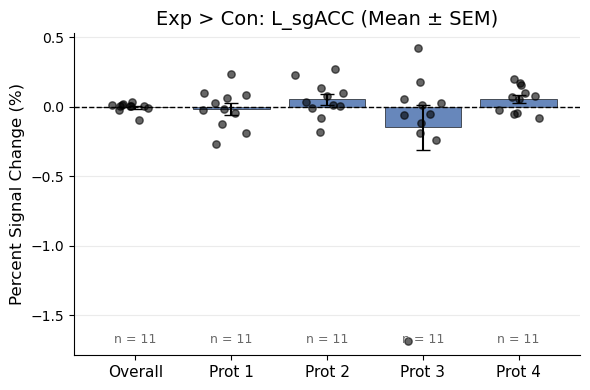

In [27]:
plot_exp_gt_con_bar_pretty(
    roi_data=roi_data_all,
    roi_names=["sgACC_BA25_L"],
    save_path=roi_dir / "bar_exp_gt_con_sgACC_pretty.png",
)